# VC State Score Annotation

Samples transcripts from `collapsed-role-collapsed-turn-sentence-stratified_sample.csv` and prepares annotation files for state classification and scoring.

**RAs:** Joyce, Shiyu (both annotate all sampled transcripts)  
**Unit:** One row per CSR turn. `customer` = preceding customer utterance (or `NA` if CSR speaks first). `CSR` = CSR response.  
**Annotation columns:** `state`, `state_score` (0–2), `note`

# 1st Round

## 1. Setup

In [22]:
import os
import random
import pandas as pd

SEED      = 42
ROUND_NUM = 1
N_SAMPLE  = 5
RA_NAMES  = ["joyce", "shiyu"]

TURNS_CSV    = "data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv"
TRACKING_CSV = "data/vc/sampled_filenames.csv"
OUTPUT_DIR   = "data/vc/state_score/1st_round"

ANNOTATION_COLS = ["state", "state_score", "note"]

print(f"Design: {N_SAMPLE} transcripts, both RAs annotate all ({', '.join(RA_NAMES)})")

Design: 5 transcripts, both RAs annotate all (joyce, shiyu)


## 2. Sample Transcripts

In [23]:
print(f"Loading turns from {TURNS_CSV}...")
turns_df = pd.read_csv(TURNS_CSV, low_memory=False)
print(f"  {len(turns_df):,} turns across {turns_df['filename'].nunique():,} transcripts")

# Load or initialize tracking
if os.path.exists(TRACKING_CSV):
    tracking = pd.read_csv(TRACKING_CSV)
else:
    tracking = pd.DataFrame(columns=["round", "source_folder", "filename"])

# Exclude transcripts sampled in prior rounds only
prior = tracking[tracking["round"] < ROUND_NUM]
already_sampled = set(zip(prior["source_folder"], prior["filename"]))
print(f"Excluding {len(already_sampled)} transcripts from rounds 1–{ROUND_NUM - 1}")

all_available = (
    turns_df[["source_folder", "filename"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)
available = [x for x in all_available if x not in already_sampled]
print(f"Available: {len(available)}")
assert len(available) >= N_SAMPLE, f"Not enough transcripts: need {N_SAMPLE}, have {len(available)}"

random.seed(SEED)
sampled = random.sample(available, N_SAMPLE)

print(f"\nSampled {N_SAMPLE} transcripts:")
for sf, fn in sampled:
    print(f"  [{sf}] {fn}")

Loading turns from data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv...
  382,082 turns across 5,910 transcripts
Excluding 0 transcripts from rounds 1–0
Available: 5999

Sampled 5 transcripts:
  [medicare_inbound] 332305100030452long_transcript.json
  [auto_insurance_customer_service_inbound] 2020-10-06-18-12-43_d73f290a-fe6b-48f1-8b6e-0263d9e6b5f9_v2TUI350t_U9RbiyhHs7-PPn9wzoOR26982k7SwiW28T3exjZEeFLgkA_transcript.json
  [auto_insurance_customer_service_inbound] 2020-05-06-16-26-26_a9d4d5da-c4ca-4f9a-86b9-2f3a051b77a8_v2hNj7HAEu4RSFO3aJ5pD3elCpXYulizYojIZg-TRA-VeFbF6hyO6E4w_transcript.json
  [automotive_inbound] 332305240006434long_transcript.json
  [automotive_inbound] 01ba44d3b2b74c3fa66f0707dffb987c_transcript.json


## 3. Generate Annotation Files

In [3]:
def build_exchanges(transcript_df):
    """
    One row per CSR turn.
    customer = preceding customer utterance, or 'NA' if CSR speaks first.
    """
    rows = []
    turns = transcript_df.sort_values("turn_number").reset_index(drop=True)
    i = 0

    # If transcript opens with CSR, emit a row with customer=NA
    if len(turns) > 0 and turns.iloc[0]["speaker_role"] == "CSR":
        rows.append({"customer": "NA", "CSR": turns.iloc[0]["text"]})
        i = 1

    # Pair remaining turns: each customer turn + the CSR turn that follows
    while i < len(turns):
        curr = turns.iloc[i]
        if curr["speaker_role"] == "customer" and i + 1 < len(turns):
            nxt = turns.iloc[i + 1]
            if nxt["speaker_role"] == "CSR":
                rows.append({"customer": curr["text"], "CSR": nxt["text"]})
                i += 2
            else:
                i += 1
        else:
            i += 1

    return rows


os.makedirs(OUTPUT_DIR, exist_ok=True)

for ra in RA_NAMES:
    rows = []
    for sf, fn in sampled:
        sub = turns_df[
            (turns_df["source_folder"] == sf) & (turns_df["filename"] == fn)
        ]
        for seg_num, exchange in enumerate(build_exchanges(sub), start=1):
            rows.append({"source_folder": sf, "filename": fn, "segment": seg_num, **exchange})

    out_df = pd.DataFrame(rows, columns=["source_folder", "filename", "segment", "customer", "CSR"] + ANNOTATION_COLS)
    for col in ANNOTATION_COLS:
        out_df[col] = ""

    out_path = os.path.join(OUTPUT_DIR, f"round{ROUND_NUM}_{ra}.csv")
    out_df.to_csv(out_path, index=False)
    print(f"{ra}: {out_df['filename'].nunique()} transcripts, {len(out_df)} exchanges → {out_path}")

joyce: 5 transcripts, 220 exchanges → data/vc/state_score/1st_round/round1_joyce.csv
shiyu: 5 transcripts, 220 exchanges → data/vc/state_score/1st_round/round1_shiyu.csv


## 4. Update Tracking

In [ ]:
if ROUND_NUM in tracking["round"].values:
    print(f"Round {ROUND_NUM} already in tracking — skipping update.")
else:
    new_rows = pd.DataFrame([
        {"round": ROUND_NUM, "source_folder": sf, "filename": fn}
        for sf, fn in sampled
    ])
    tracking = pd.concat([tracking, new_rows], ignore_index=True)
    os.makedirs(os.path.dirname(TRACKING_CSV), exist_ok=True)
    tracking.to_csv(TRACKING_CSV, index=False)
    print(f"Tracking updated: {len(new_rows)} new filenames added (round {ROUND_NUM})")

print(f"Total sampled across all rounds: {len(tracking)}")
print(tracking.groupby('round').size().rename('count'))

## 5. Agreement Analysis

Computes inter-rater agreement between Joyce and Shiyu on the segments Shiyu has completed. Agreement metrics:
- **`state`** — Cohen's κ (unweighted, categorical)
- **`state_score`** — weighted Cohen's κ (linear) + ICC(A,1) (ordinal 0–2)

In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

KEY_COLS = ['source_folder', 'filename', 'segment']

# Load completed annotation files
joyce = pd.read_excel(os.path.join(OUTPUT_DIR, 'round1_joyce_completed.xlsx'))
shiyu = pd.read_csv(os.path.join(OUTPUT_DIR, 'round1_shiyu_completed.csv'))

# Normalize state labels: lowercase + fix Joyce's typo
def normalize_state(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if s == 'prblem interpretation':
        s = 'problem interpretation'
    return s

joyce['state'] = joyce['state'].map(normalize_state)
shiyu['state'] = shiyu['state'].map(normalize_state)

# Keep only rows where Shiyu has completed both state and state_score
shiyu_done = shiyu.dropna(subset=['state', 'state_score'])
print(f"Joyce:      {len(joyce)} segments (all complete)")
print(f"Shiyu:      {len(shiyu)} segments total, {len(shiyu_done)} complete, {len(shiyu) - len(shiyu_done)} pending")

# Merge on shared completed rows
merged = joyce[KEY_COLS + ['state', 'state_score']].rename(
    columns={'state': 'state_joyce', 'state_score': 'score_joyce'}
).merge(
    shiyu_done[KEY_COLS + ['state', 'state_score']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'score_shiyu'}
    ),
    on=KEY_COLS
)
print(f"Overlap for agreement: {len(merged)} segments\n")

# --- state: Cohen's κ (unweighted) ---
state_labels = sorted(set(merged['state_joyce'].dropna()) | set(merged['state_shiyu'].dropna()))
kappa_state = cohen_kappa_score(merged['state_joyce'], merged['state_shiyu'], labels=state_labels)
print(f"=== State label agreement (n={len(merged)}) ===")
print(f"Cohen's κ (unweighted): {kappa_state:.3f}\n")

# Cross-tab
ct = pd.crosstab(merged['state_joyce'], merged['state_shiyu'],
                 rownames=['Joyce'], colnames=['Shiyu'])
display(ct)

Joyce:      220 segments (all complete)
Shiyu:      220 segments total, 147 complete, 73 pending
Overlap for agreement: 147 segments

=== State label agreement (n=147) ===
Cohen's κ (unweighted): 0.699



Shiyu,problem exploration,problem interpretation,problem resolution
Joyce,,,
problem exploration,76,4,5
problem interpretation,1,23,3
problem resolution,4,9,22


### 5.1 State Score Agreement — Matching-State Rows Only

Score agreement computed only on segments where both RAs assigned the same state label, since `state_score` rates execution quality *within* a state and cross-state comparisons are uninterpretable.

In [25]:
# Restrict to segments where both RAs agree on state
same_state = merged[merged['state_joyce'] == merged['state_shiyu']].copy()
print(f"Matching-state segments: {len(same_state)} / {len(merged)} "
      f"({100 * len(same_state) / len(merged):.1f}%)\n")

# Overall score agreement on matching-state rows
scores_j = same_state['score_joyce'].astype(int)
scores_s = same_state['score_shiyu'].astype(int)

kappa_uw = cohen_kappa_score(scores_j, scores_s, labels=[0, 1, 2])
kappa_w  = cohen_kappa_score(scores_j, scores_s, weights='linear', labels=[0, 1, 2])
long = pd.DataFrame({
    'item':   list(range(len(same_state))) * 2,
    'rater':  ['joyce'] * len(same_state) + ['shiyu'] * len(same_state),
    'rating': scores_j.tolist() + scores_s.tolist(),
})
icc_row = pg.intraclass_corr(data=long, targets='item', raters='rater', ratings='rating')
icc_row = icc_row[icc_row['Type'] == 'ICC(A,1)'].iloc[0]

print(f"=== State score agreement — matching-state rows (n={len(same_state)}) ===")
print(f"Cohen's κ (unweighted):      {kappa_uw:.3f}")
print(f"Weighted Cohen's κ (linear): {kappa_w:.3f}")
print(f"ICC(A,1):                    {icc_row['ICC']:.3f}  "
      f"95% CI [{icc_row['CI95'][0]:.3f}, {icc_row['CI95'][1]:.3f}]  p={icc_row['pval']:.4f}\n")

# Per-state breakdown
print("=== Per-state breakdown ===")
rows = []
for state, grp in same_state.groupby('state_joyce'):
    n = len(grp)
    if n < 5:
        rows.append({'State': state, 'n': n, 'κ (unweighted)': 'too few',
                     'κ (linear)': '', 'ICC(A,1)': ''})
        continue
    k_uw = cohen_kappa_score(grp['score_joyce'].astype(int), grp['score_shiyu'].astype(int),
                             labels=[0, 1, 2])
    k_w  = cohen_kappa_score(grp['score_joyce'].astype(int), grp['score_shiyu'].astype(int),
                             weights='linear', labels=[0, 1, 2])
    lng = pd.DataFrame({
        'item':   list(range(n)) * 2,
        'rater':  ['joyce'] * n + ['shiyu'] * n,
        'rating': grp['score_joyce'].astype(int).tolist() + grp['score_shiyu'].astype(int).tolist(),
    })
    res = pg.intraclass_corr(data=lng, targets='item', raters='rater', ratings='rating')
    icc = res[res['Type'] == 'ICC(A,1)'].iloc[0]
    rows.append({
        'State': state, 'n': n,
        'κ (unweighted)': round(k_uw, 3),
        'κ (linear)':     round(k_w, 3),
        'ICC(A,1)': f"{icc['ICC']:.3f}  [{icc['CI95'][0]:.3f}, {icc['CI95'][1]:.3f}]",
    })
display(pd.DataFrame(rows).set_index('State'))

Matching-state segments: 121 / 147 (82.3%)

=== State score agreement — matching-state rows (n=121) ===
Cohen's κ (unweighted):      0.450
Weighted Cohen's κ (linear): 0.513
ICC(A,1):                    0.585  95% CI [0.450, 0.690]  p=0.0000

=== Per-state breakdown ===


,n,κ (unweighted),κ (linear),"ICC(A,1)"
State,,,,
problem exploration,76,0.351,0.408,"0.487 [0.300, 0.640]"
problem interpretation,23,0.000,0.000,"0.000 [-0.380, 0.390]"
problem resolution,22,0.254,0.239,"0.231 [-0.220, 0.590]"


## 6. Combined Annotations CSV

Merges both RAs' annotations into a single file with `customer` and `CSR` text columns included. All 220 rows are kept; Shiyu's pending segments have NaN in her annotation columns. Output: `round1_combined.csv`.

In [7]:
# joyce and shiyu already loaded and normalized from Section 5
# Use full shiyu (not just shiyu_done) so all 220 rows are retained
combined = joyce[KEY_COLS + ['customer', 'CSR', 'state', 'state_score', 'note']].rename(
    columns={'state': 'state_joyce', 'state_score': 'state_score_joyce', 'note': 'note_joyce'}
).merge(
    shiyu[KEY_COLS + ['state', 'state_score', 'note']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'state_score_shiyu', 'note': 'note_shiyu'}
    ),
    on=KEY_COLS,
    how='left'
)

# Derived columns — NaN where either RA's annotation is missing
combined['state_difference'] = combined.apply(
    lambda r: 0 if r['state_joyce'] == r['state_shiyu'] else 1
    if pd.notna(r['state_joyce']) and pd.notna(r['state_shiyu']) else np.nan,
    axis=1
)
combined['score_difference'] = (
    combined['state_score_joyce'] - combined['state_score_shiyu']
).abs()

out_path = os.path.join(OUTPUT_DIR, 'round1_combined.csv')
combined.to_csv(out_path, index=False)

n_both = combined[['state_joyce', 'state_shiyu']].notna().all(axis=1).sum()
print(f"Saved {len(combined)} rows × {len(combined.columns)} cols → {out_path}")
print(f"Both annotated: {n_both} / {len(combined)}  |  Shiyu pending: {len(combined) - n_both}")
print(f"\nstate_difference:  {combined['state_difference'].value_counts().sort_index().to_dict()}")
print(f"score_difference:  {combined['score_difference'].value_counts().sort_index().to_dict()}")
display(combined.head(3))

Saved 220 rows × 13 cols → data/vc/state_score/1st_round/round1_combined.csv
Both annotated: 147 / 220  |  Shiyu pending: 73

state_difference:  {0.0: 121, 1.0: 26}
score_difference:  {0.0: 91, 1.0: 46, 2.0: 10}


,source_folder,filename,segment,customer,CSR,state_joyce,state_score_joyce,note_joyce,state_shiyu,state_score_shiyu,note_shiyu,state_difference,score_difference
0,medicare_inbound,332305100030452long_transcript.json,1,NaN,Thank you for calling [ORGANIZATION] [ORGANIZA...,problem interpretation,0,just the opening,problem interpretation,0.0,courtesy,0.0,0.0
1,medicare_inbound,332305100030452long_transcript.json,2,"Hi, I'JUST like to make an appointment for my ...","Okay, and do we know anybody else in your fami...",problem exploration,0,procedural question,problem exploration,0.0,NaN,0.0,0.0
2,medicare_inbound,332305100030452long_transcript.json,3,"Well, it's kind of unique. My daughter was ref...","Gotcha. All right, so I already have some info...",problem exploration,0,confirming the information(procedure),problem exploration,0.0,NaN,0.0,0.0


# 2nd Round

## 1. Setup

In [26]:
SEED      = 42
ROUND_NUM = 2
N_SAMPLE  = 3
RA_NAMES  = ["joyce", "shiyu"]

TURNS_CSV    = "data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv"
TRACKING_CSV = "data/vc/sampled_filenames.csv"
OUTPUT_DIR   = "data/vc/state_score/2nd_round"

ANNOTATION_COLS = ["state", "state_score", "note"]

print(f"Design: {N_SAMPLE} transcripts, both RAs annotate all ({', '.join(RA_NAMES)})")

Design: 3 transcripts, both RAs annotate all (joyce, shiyu)


## 2. Sample Transcripts

In [27]:
print(f"Loading turns from {TURNS_CSV}...")
turns_df = pd.read_csv(TURNS_CSV, low_memory=False)
print(f"  {len(turns_df):,} turns across {turns_df['filename'].nunique():,} transcripts")

# Load tracking and exclude all previously sampled transcripts
tracking = pd.read_csv(TRACKING_CSV)
prior = tracking[tracking["round"] < ROUND_NUM]
already_sampled = set(zip(prior["source_folder"], prior["filename"]))
print(f"Excluding {len(already_sampled)} transcripts from rounds 1–{ROUND_NUM - 1}")

all_available = (
    turns_df[["source_folder", "filename"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)
available = [x for x in all_available if x not in already_sampled]
print(f"Available: {len(available)}")
assert len(available) >= N_SAMPLE, f"Not enough transcripts: need {N_SAMPLE}, have {len(available)}"

random.seed(SEED)
sampled = random.sample(available, N_SAMPLE)

print(f"\nSampled {N_SAMPLE} transcripts:")
for sf, fn in sampled:
    print(f"  [{sf}] {fn}")

Loading turns from data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv...
  382,082 turns across 5,910 transcripts
Excluding 5 transcripts from rounds 1–1
Available: 5994

Sampled 3 transcripts:
  [medicare_inbound] 332305140017025long_transcript.json
  [auto_insurance_customer_service_inbound] 2020-10-06-19-26-43_941e637d-17c6-424e-9d76-32927d6635e7_v2aA1gI7tqgI0FWYmnJfdE-igYjrhcyqHUnMJQi27ESSPzd_Q4YKT8Pg_transcript.json
  [auto_insurance_customer_service_inbound] 2020-05-06-16-45-09_093e860a-429f-4c51-a2ff-737c3bd36c5c_v2Xgm44wsKHBpz3yHwXl2J2A3gHfkkliRsZkPLfc1MnZknOOTpxf3H9w_transcript.json


## 3. Generate Annotation Files

In [28]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

for ra in RA_NAMES:
    rows = []
    for sf, fn in sampled:
        sub = turns_df[
            (turns_df["source_folder"] == sf) & (turns_df["filename"] == fn)
        ]
        for seg_num, exchange in enumerate(build_exchanges(sub), start=1):
            rows.append({"source_folder": sf, "filename": fn, "segment": seg_num, **exchange})

    out_df = pd.DataFrame(rows, columns=["source_folder", "filename", "segment", "customer", "CSR"] + ANNOTATION_COLS)
    for col in ANNOTATION_COLS:
        out_df[col] = ""

    out_path = os.path.join(OUTPUT_DIR, f"round{ROUND_NUM}_{ra}.csv")
    out_df.to_csv(out_path, index=False)
    print(f"{ra}: {out_df['filename'].nunique()} transcripts, {len(out_df)} exchanges → {out_path}")

joyce: 3 transcripts, 95 exchanges → data/vc/state_score/2nd_round/round2_joyce.csv
shiyu: 3 transcripts, 95 exchanges → data/vc/state_score/2nd_round/round2_shiyu.csv


## 4. Update Tracking

In [29]:
if ROUND_NUM in tracking["round"].values:
    print(f"Round {ROUND_NUM} already in tracking — skipping update.")
else:
    new_rows = pd.DataFrame([
        {"round": ROUND_NUM, "source_folder": sf, "filename": fn}
        for sf, fn in sampled
    ])
    tracking = pd.concat([tracking, new_rows], ignore_index=True)
    os.makedirs(os.path.dirname(TRACKING_CSV), exist_ok=True)
    tracking.to_csv(TRACKING_CSV, index=False)
    print(f"Tracking updated: {len(new_rows)} new filenames added (round {ROUND_NUM})")

print(f"Total sampled across all rounds: {len(tracking)}")
print(tracking.groupby('round').size().rename('count'))

Round 2 already in tracking — skipping update.
Total sampled across all rounds: 8
round
1    5
2    3
Name: count, dtype: int64


## 5. Agreement Analysis

Computes inter-rater agreement between Joyce and Shiyu on all 95 completed segments. Agreement metrics:
- **`state`** — Cohen's κ (unweighted, categorical)
- **`state_score`** — weighted Cohen's κ (linear) + ICC(A,1) (ordinal 0–2)

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

KEY_COLS = ['source_folder', 'filename', 'segment']

# Load completed annotation files (both CSVs for round 2)
joyce = pd.read_csv(os.path.join(OUTPUT_DIR, 'round2_joyce_completed.csv'))
shiyu = pd.read_csv(os.path.join(OUTPUT_DIR, 'round2_shiyu_completed.csv'))

# Normalize state labels: lowercase
def normalize_state(s):
    if pd.isna(s):
        return np.nan
    return str(s).strip().lower()

joyce['state'] = joyce['state'].map(normalize_state)
shiyu['state'] = shiyu['state'].map(normalize_state)

print(f"Joyce: {len(joyce)} segments (all complete)")
print(f"Shiyu: {len(shiyu)} segments (all complete)")

# Merge on all rows
merged = joyce[KEY_COLS + ['state', 'state_score']].rename(
    columns={'state': 'state_joyce', 'state_score': 'score_joyce'}
).merge(
    shiyu[KEY_COLS + ['state', 'state_score']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'score_shiyu'}
    ),
    on=KEY_COLS
)
print(f"Overlap for agreement: {len(merged)} segments\n")

# --- state: Cohen's κ (unweighted) ---
state_labels = sorted(set(merged['state_joyce'].dropna()) | set(merged['state_shiyu'].dropna()))
kappa_state = cohen_kappa_score(merged['state_joyce'], merged['state_shiyu'], labels=state_labels)
print(f"=== State label agreement (n={len(merged)}) ===")
print(f"Cohen's κ (unweighted): {kappa_state:.3f}\n")

# Cross-tab
ct = pd.crosstab(merged['state_joyce'], merged['state_shiyu'],
                 rownames=['Joyce'], colnames=['Shiyu'])
display(ct)

Joyce: 95 segments (all complete)
Shiyu: 95 segments (all complete)
Overlap for agreement: 95 segments

=== State label agreement (n=95) ===
Cohen's κ (unweighted): 0.892



Shiyu,problem exploration,problem interpretation,problem resolution
Joyce,,,
problem exploration,49,0,1
problem interpretation,2,9,2
problem resolution,0,1,31


### 5.1 State Score Agreement — Matching-State Rows Only

Score agreement computed only on segments where both RAs assigned the same state label, since `state_score` rates execution quality *within* a state and cross-state comparisons are uninterpretable.

In [31]:
# Restrict to segments where both RAs agree on state
same_state = merged[merged['state_joyce'] == merged['state_shiyu']].copy()
print(f"Matching-state segments: {len(same_state)} / {len(merged)} "
      f"({100 * len(same_state) / len(merged):.1f}%)\n")

# Overall score agreement on matching-state rows
scores_j = same_state['score_joyce'].astype(int)
scores_s = same_state['score_shiyu'].astype(int)

kappa_uw = cohen_kappa_score(scores_j, scores_s, labels=[0, 1, 2])
kappa_w  = cohen_kappa_score(scores_j, scores_s, weights='linear', labels=[0, 1, 2])
long = pd.DataFrame({
    'item':   list(range(len(same_state))) * 2,
    'rater':  ['joyce'] * len(same_state) + ['shiyu'] * len(same_state),
    'rating': scores_j.tolist() + scores_s.tolist(),
})
icc_res = pg.intraclass_corr(data=long, targets='item', raters='rater', ratings='rating')
icc_row = icc_res[icc_res['Type'] == 'ICC(A,1)'].iloc[0]

print(f"=== State score agreement — matching-state rows (n={len(same_state)}) ===")
print(f"Cohen's κ (unweighted):      {kappa_uw:.3f}")
print(f"Weighted Cohen's κ (linear): {kappa_w:.3f}")
print(f"ICC(A,1):                    {icc_row['ICC']:.3f}  "
      f"95% CI [{icc_row['CI95'][0]:.3f}, {icc_row['CI95'][1]:.3f}]  p={icc_row['pval']:.4f}\n")

# Per-state breakdown
print("=== Per-state breakdown ===")
rows = []
for state, grp in same_state.groupby('state_joyce'):
    n = len(grp)
    if n < 5:
        rows.append({'State': state, 'n': n, 'κ (unweighted)': 'too few',
                     'κ (linear)': '', 'ICC(A,1)': ''})
        continue
    k_uw = cohen_kappa_score(grp['score_joyce'].astype(int), grp['score_shiyu'].astype(int),
                             labels=[0, 1, 2])
    k_w  = cohen_kappa_score(grp['score_joyce'].astype(int), grp['score_shiyu'].astype(int),
                             weights='linear', labels=[0, 1, 2])
    lng = pd.DataFrame({
        'item':   list(range(n)) * 2,
        'rater':  ['joyce'] * n + ['shiyu'] * n,
        'rating': grp['score_joyce'].astype(int).tolist() + grp['score_shiyu'].astype(int).tolist(),
    })
    res = pg.intraclass_corr(data=lng, targets='item', raters='rater', ratings='rating')
    icc = res[res['Type'] == 'ICC(A,1)'].iloc[0]
    rows.append({
        'State': state, 'n': n,
        'κ (unweighted)': round(k_uw, 3),
        'κ (linear)':     round(k_w, 3),
        'ICC(A,1)': f"{icc['ICC']:.3f}  [{icc['CI95'][0]:.3f}, {icc['CI95'][1]:.3f}]",
    })
display(pd.DataFrame(rows).set_index('State'))

Matching-state segments: 89 / 95 (93.7%)

=== State score agreement — matching-state rows (n=89) ===
Cohen's κ (unweighted):      0.160
Weighted Cohen's κ (linear): 0.300
ICC(A,1):                    0.464  95% CI [0.280, 0.620]  p=0.0000

=== Per-state breakdown ===


,n,κ (unweighted),κ (linear),"ICC(A,1)"
State,,,,
problem exploration,49,-0.005,0.022,"0.074 [-0.120, 0.290]"
problem interpretation,9,0.609,0.609,"0.636 [0.040, 0.900]"
problem resolution,31,0.102,0.215,"0.341 [-0.020, 0.620]"


### 5.2 Score Distribution by State and RA

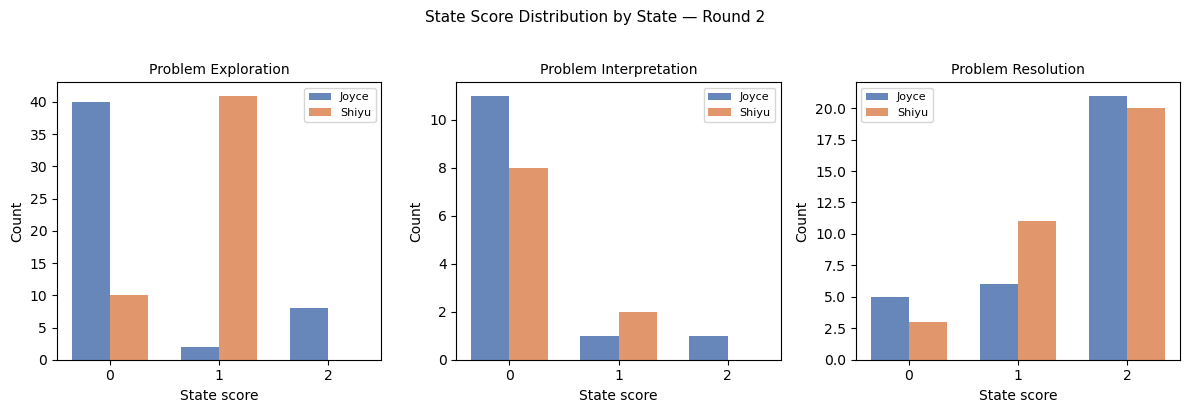

Mean ± SD of state_score per RA per state:


,Joyce mean±SD,Shiyu mean±SD
State,,
Problem Exploration,0.36 ± 0.75 (n=50),0.80 ± 0.40 (n=51)
Problem Interpretation,0.23 ± 0.60 (n=13),0.20 ± 0.42 (n=10)
Problem Resolution,1.50 ± 0.76 (n=32),1.50 ± 0.66 (n=34)


In [32]:
import matplotlib.pyplot as plt
import numpy as np

states = sorted(merged['state_joyce'].dropna().unique())
score_vals = [0, 1, 2]
ra_colors = {'joyce': '#4C72B0', 'shiyu': '#DD8452'}
width = 0.35
x = np.arange(len(score_vals))

fig, axes = plt.subplots(1, len(states), figsize=(4 * len(states), 4), sharey=False)
if len(states) == 1:
    axes = [axes]

for ax, state in zip(axes, states):
    # Use all rows per RA (not just matching-state), filtered by their own label
    j_counts = joyce[joyce['state'] == state]['state_score'].value_counts().reindex(score_vals, fill_value=0)
    s_counts = shiyu[shiyu['state'] == state]['state_score'].value_counts().reindex(score_vals, fill_value=0)

    ax.bar(x - width / 2, j_counts.values, width, label='Joyce', color=ra_colors['joyce'], alpha=0.85)
    ax.bar(x + width / 2, s_counts.values, width, label='Shiyu', color=ra_colors['shiyu'], alpha=0.85)

    ax.set_title(state.title(), fontsize=10)
    ax.set_xlabel('State score')
    ax.set_xticks(x)
    ax.set_xticklabels(score_vals)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('State Score Distribution by State — Round 2', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Summary table: mean ± SD per RA per state
print("Mean ± SD of state_score per RA per state:")
rows = []
for state in states:
    row = {'State': state.title()}
    for ra, df in [('Joyce', joyce), ('Shiyu', shiyu)]:
        vals = df[df['state'] == state]['state_score'].dropna()
        row[f'{ra} mean±SD'] = f"{vals.mean():.2f} ± {vals.std():.2f}  (n={len(vals)})"
    rows.append(row)
display(pd.DataFrame(rows).set_index('State'))

## 6. Combined Annotations CSV

Merges both RAs' annotations into a single file with `customer` and `CSR` text columns included. All 95 rows are retained. Output: `round2_combined.csv`.

In [33]:
# joyce and shiyu already loaded and normalized from Section 5
combined = joyce[KEY_COLS + ['customer', 'CSR', 'state', 'state_score', 'note']].rename(
    columns={'state': 'state_joyce', 'state_score': 'state_score_joyce', 'note': 'note_joyce'}
).merge(
    shiyu[KEY_COLS + ['state', 'state_score', 'note']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'state_score_shiyu', 'note': 'note_shiyu'}
    ),
    on=KEY_COLS,
    how='left'
)

# Derived columns
combined['state_difference'] = combined.apply(
    lambda r: 0 if r['state_joyce'] == r['state_shiyu'] else 1
    if pd.notna(r['state_joyce']) and pd.notna(r['state_shiyu']) else np.nan,
    axis=1
)
combined['score_difference'] = (
    combined['state_score_joyce'] - combined['state_score_shiyu']
).abs()

out_path = os.path.join(OUTPUT_DIR, 'round2_combined.csv')
combined.to_csv(out_path, index=False)

n_both = combined[['state_joyce', 'state_shiyu']].notna().all(axis=1).sum()
print(f"Saved {len(combined)} rows × {len(combined.columns)} cols → {out_path}")
print(f"Both annotated: {n_both} / {len(combined)}")
print(f"\nstate_difference:  {combined['state_difference'].value_counts().sort_index().to_dict()}")
print(f"score_difference:  {combined['score_difference'].value_counts().sort_index().to_dict()}")
display(combined.head(3))

Saved 95 rows × 13 cols → data/vc/state_score/2nd_round/round2_combined.csv
Both annotated: 95 / 95

state_difference:  {0: 89, 1: 6}
score_difference:  {0: 35, 1: 57, 2: 3}


,source_folder,filename,segment,customer,CSR,state_joyce,state_score_joyce,note_joyce,state_shiyu,state_score_shiyu,note_shiyu,state_difference,score_difference
0,medicare_inbound,332305140017025long_transcript.json,1,NaN,Thank you for calling [ORGANIZATION] [ORGANIZA...,problem interpretation,0,NaN,problem interpretation,0,NaN,0,0
1,medicare_inbound,332305140017025long_transcript.json,2,"Hi, [PERSON_NAME], My name is [PERSON_NAME]. I...","Oh, I got you. Give me just a super quick sec....",problem resolution,0,NaN,problem resolution,2,NaN,0,2
2,medicare_inbound,332305140017025long_transcript.json,3,Like I when there should be a resolution on th...,Is there a specific patient that we're looking...,problem exploration,2,NaN,problem exploration,1,NaN,0,1


# 3rd Round

## 1. Setup

In [42]:
SEED      = 42
ROUND_NUM = 3
N_SAMPLE  = 2
RA_NAMES  = ["joyce", "shiyu"]

TURNS_CSV    = "data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv"
TRACKING_CSV = "data/vc/sampled_filenames.csv"
OUTPUT_DIR   = "data/vc/state_score/3rd_round"

ANNOTATION_COLS = ["state", "state_score", "note"]

print(f"Design: {N_SAMPLE} transcripts, both RAs annotate all ({', '.join(RA_NAMES)})")

Design: 2 transcripts, both RAs annotate all (joyce, shiyu)


## 2. Sample Transcripts

In [43]:
print(f"Loading turns from {TURNS_CSV}...")
turns_df = pd.read_csv(TURNS_CSV, low_memory=False)
print(f"  {len(turns_df):,} turns across {turns_df['filename'].nunique():,} transcripts")

# Load tracking and exclude all previously sampled transcripts
tracking = pd.read_csv(TRACKING_CSV)
prior = tracking[tracking["round"] < ROUND_NUM]
already_sampled = set(zip(prior["source_folder"], prior["filename"]))
print(f"Excluding {len(already_sampled)} transcripts from rounds 1–{ROUND_NUM - 1}")

# Filter: only transcripts with <50 CSR turns (= <50 segments after build_exchanges)
csr_counts = (
    turns_df[turns_df["speaker_role"] == "CSR"]
    .groupby(["source_folder", "filename"])
    .size()
)
small_transcripts = set(csr_counts[csr_counts < 50].index)
print(f"Transcripts with <50 segments: {len(small_transcripts)}")

all_available = (
    turns_df[["source_folder", "filename"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)
available = [x for x in all_available if x not in already_sampled and x in small_transcripts]
print(f"Available after filters: {len(available)}")
assert len(available) >= N_SAMPLE, f"Not enough transcripts: need {N_SAMPLE}, have {len(available)}"

random.seed(SEED)
sampled = random.sample(available, N_SAMPLE)

print(f"\nSampled {N_SAMPLE} transcripts:")
for sf, fn in sampled:
    print(f"  [{sf}] {fn}")

Loading turns from data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv...
  382,082 turns across 5,910 transcripts
Excluding 8 transcripts from rounds 1–2
Transcripts with <50 segments: 5021
Available after filters: 5015

Sampled 2 transcripts:
  [automotive_and_healthcare_insurance_inbound] 2021-08-12-14-28-02_5c5372da-5e79-4bac-9dc3-db4dd582db18_v2GqQf5Ypu6cz8Dotho2rycL3vQNRUjGcWm6G8vZTAL1tPwmib1SOZ2w_transcript.json
  [auto_insurance_customer_service_inbound] 2020-07-20-16-16-44_b0550aa7-3ce7-474e-b145-70adfca44d75_v2ZYRyAPyy5yBpI3crPqXqz1sBjvcZW8ZmdzC2sM4lBqZMfq8zK4GcoQ_transcript.json


## 3. Generate Annotation Files

In [44]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

for ra in RA_NAMES:
    rows = []
    for sf, fn in sampled:
        sub = turns_df[
            (turns_df["source_folder"] == sf) & (turns_df["filename"] == fn)
        ]
        for seg_num, exchange in enumerate(build_exchanges(sub), start=1):
            rows.append({"source_folder": sf, "filename": fn, "segment": seg_num, **exchange})

    out_df = pd.DataFrame(rows, columns=["source_folder", "filename", "segment", "customer", "CSR"] + ANNOTATION_COLS)
    for col in ANNOTATION_COLS:
        out_df[col] = ""

    out_path = os.path.join(OUTPUT_DIR, f"round{ROUND_NUM}_{ra}.csv")
    out_df.to_csv(out_path, index=False)
    print(f"{ra}: {out_df['filename'].nunique()} transcripts, {len(out_df)} exchanges → {out_path}")

joyce: 2 transcripts, 60 exchanges → data/vc/state_score/3rd_round/round3_joyce.csv
shiyu: 2 transcripts, 60 exchanges → data/vc/state_score/3rd_round/round3_shiyu.csv


## 4. Update Tracking

In [46]:
if ROUND_NUM in tracking["round"].values:
    print(f"Round {ROUND_NUM} already in tracking — skipping update.")
else:
    new_rows = pd.DataFrame([
        {"round": ROUND_NUM, "source_folder": sf, "filename": fn}
        for sf, fn in sampled
    ])
    tracking = pd.concat([tracking, new_rows], ignore_index=True)
    os.makedirs(os.path.dirname(TRACKING_CSV), exist_ok=True)
    tracking.to_csv(TRACKING_CSV, index=False)
    print(f"Tracking updated: {len(new_rows)} new filenames added (round {ROUND_NUM})")

print(f"Total sampled across all rounds: {len(tracking)}")
print(tracking.groupby('round').size().rename('count'))

Round 3 already in tracking — skipping update.
Total sampled across all rounds: 10
round
1    5
2    3
3    2
Name: count, dtype: int64


## 5. Agreement Analysis

Computes inter-rater agreement between Joyce and Shiyu on all completed segments. Agreement metrics:
- **`state`** — Cohen's κ (unweighted, categorical)
- **`state_score`** — weighted Cohen's κ (linear) + ICC(A,1) (ordinal 0–2)

In [48]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

KEY_COLS = ['source_folder', 'filename', 'segment']

# Load completed annotation files
joyce = pd.read_csv(os.path.join(OUTPUT_DIR, 'round3_joyce_completed.csv'))
shiyu = pd.read_csv(os.path.join(OUTPUT_DIR, 'round3_shiyu_completed.csv'))

# Normalize state labels: lowercase
def normalize_state(s):
    if pd.isna(s):
        return np.nan
    return str(s).strip().lower()

joyce['state'] = joyce['state'].map(normalize_state)
shiyu['state'] = shiyu['state'].map(normalize_state)

print(f"Joyce: {len(joyce)} segments (all complete)")
print(f"Shiyu: {len(shiyu)} segments (all complete)")

# Merge on all rows
merged = joyce[KEY_COLS + ['state', 'state_score']].rename(
    columns={'state': 'state_joyce', 'state_score': 'score_joyce'}
).merge(
    shiyu[KEY_COLS + ['state', 'state_score']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'score_shiyu'}
    ),
    on=KEY_COLS
)
print(f"Overlap for agreement: {len(merged)} segments\n")

# --- state: Cohen's κ (unweighted) ---
state_labels = sorted(set(merged['state_joyce'].dropna()) | set(merged['state_shiyu'].dropna()))
kappa_state = cohen_kappa_score(merged['state_joyce'], merged['state_shiyu'], labels=state_labels)
print(f"=== State label agreement (n={len(merged)}) ===")
print(f"Cohen's κ (unweighted): {kappa_state:.3f}\n")

# Cross-tab
ct = pd.crosstab(merged['state_joyce'], merged['state_shiyu'],
                 rownames=['Joyce'], colnames=['Shiyu'])
display(ct)

Joyce: 60 segments (all complete)
Shiyu: 60 segments (all complete)
Overlap for agreement: 60 segments

=== State label agreement (n=60) ===
Cohen's κ (unweighted): 0.881



Shiyu,problem exploration,problem interpretation,problem resolution
Joyce,,,
problem exploration,34,1,2
problem interpretation,0,10,0
problem resolution,1,0,12


### 5.1 State Score Agreement — Matching-State Rows Only

Score agreement computed only on segments where both RAs assigned the same state label, since `state_score` rates execution quality *within* a state and cross-state comparisons are uninterpretable.

In [52]:
# Restrict to segments where both RAs agree on state
same_state = merged[merged['state_joyce'] == merged['state_shiyu']].copy()
print(f"Matching-state segments: {len(same_state)} / {len(merged)} "
      f"({100 * len(same_state) / len(merged):.1f}%)\n")

# Overall score agreement on matching-state rows
scores_j = same_state['score_joyce'].astype(int)
scores_s = same_state['score_shiyu'].astype(int)

kappa_uw = cohen_kappa_score(scores_j, scores_s, labels=[0, 1, 2])
kappa_w  = cohen_kappa_score(scores_j, scores_s, weights='linear', labels=[0, 1, 2])
long = pd.DataFrame({
    'item':   list(range(len(same_state))) * 2,
    'rater':  ['joyce'] * len(same_state) + ['shiyu'] * len(same_state),
    'rating': scores_j.tolist() + scores_s.tolist(),
})
icc_res = pg.intraclass_corr(data=long, targets='item', raters='rater', ratings='rating')
icc_row = icc_res[icc_res['Type'] == 'ICC(A,1)'].iloc[0]

print(f"=== State score agreement — matching-state rows (n={len(same_state)}) ===")
print(f"Cohen's κ (unweighted):      {kappa_uw:.3f}")
print(f"Weighted Cohen's κ (linear): {kappa_w:.3f}")
print(f"ICC(A,1):                    {icc_row['ICC']:.3f}  "
      f"95% CI [{icc_row['CI95'][0]:.3f}, {icc_row['CI95'][1]:.3f}]  p={icc_row['pval']:.4f}\n")

# Per-state breakdown
print("=== Per-state breakdown ===")
rows = []
for state, grp in same_state.groupby('state_joyce'):
    n = len(grp)
    if n < 5:
        rows.append({'State': state, 'n': n, 'κ (unweighted)': 'too few',
                     'κ (linear)': '', 'ICC(A,1)': ''})
        continue
    sj = grp['score_joyce'].astype(int)
    ss = grp['score_shiyu'].astype(int)
    # κ is undefined when one rater has zero variance (all same score)
    if sj.nunique() == 1 or ss.nunique() == 1:
        rows.append({'State': state, 'n': n, 'κ (unweighted)': 'zero var',
                     'κ (linear)': 'zero var', 'ICC(A,1)': 'zero var'})
        continue
    k_uw = cohen_kappa_score(sj, ss, labels=[0, 1, 2])
    k_w  = cohen_kappa_score(sj, ss, weights='linear', labels=[0, 1, 2])
    lng = pd.DataFrame({
        'item':   list(range(n)) * 2,
        'rater':  ['joyce'] * n + ['shiyu'] * n,
        'rating': sj.tolist() + ss.tolist(),
    })
    res = pg.intraclass_corr(data=lng, targets='item', raters='rater', ratings='rating')
    icc = res[res['Type'] == 'ICC(A,1)'].iloc[0]
    rows.append({
        'State': state, 'n': n,
        'κ (unweighted)': round(k_uw, 3),
        'κ (linear)':     round(k_w, 3),
        'ICC(A,1)': f"{icc['ICC']:.3f}  [{icc['CI95'][0]:.3f}, {icc['CI95'][1]:.3f}]",
    })
display(pd.DataFrame(rows).set_index('State'))

Matching-state segments: 56 / 60 (93.3%)

=== State score agreement — matching-state rows (n=56) ===
Cohen's κ (unweighted):      0.771
Weighted Cohen's κ (linear): 0.797
ICC(A,1):                    0.837  95% CI [0.740, 0.900]  p=0.0000

=== Per-state breakdown ===


,n,κ (unweighted),κ (linear),"ICC(A,1)"
State,,,,
problem exploration,34,0.329,0.342,"0.373 [0.040, 0.630]"
problem interpretation,10,zero var,zero var,zero var
problem resolution,12,0.867,0.889,"0.923 [0.770, 0.980]"


### 5.2 Score Distribution by State and RA

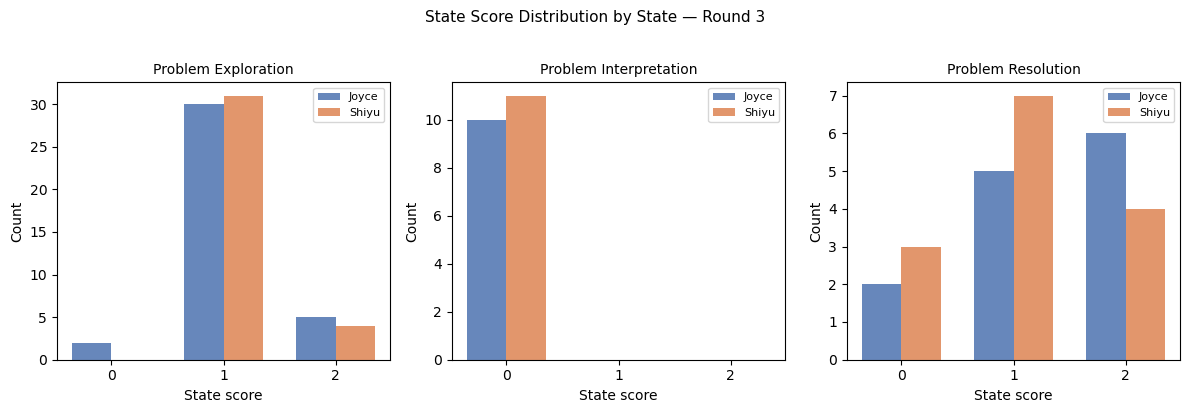

Mean ± SD of state_score per RA per state:


,Joyce mean±SD,Shiyu mean±SD
State,,
Problem Exploration,1.08 ± 0.43 (n=37),1.11 ± 0.32 (n=35)
Problem Interpretation,0.00 ± 0.00 (n=10),0.00 ± 0.00 (n=11)
Problem Resolution,1.31 ± 0.75 (n=13),1.07 ± 0.73 (n=14)


In [50]:
import matplotlib.pyplot as plt
import numpy as np

states = sorted(merged['state_joyce'].dropna().unique())
score_vals = [0, 1, 2]
ra_colors = {'joyce': '#4C72B0', 'shiyu': '#DD8452'}
width = 0.35
x = np.arange(len(score_vals))

fig, axes = plt.subplots(1, len(states), figsize=(4 * len(states), 4), sharey=False)
if len(states) == 1:
    axes = [axes]

for ax, state in zip(axes, states):
    j_counts = joyce[joyce['state'] == state]['state_score'].value_counts().reindex(score_vals, fill_value=0)
    s_counts = shiyu[shiyu['state'] == state]['state_score'].value_counts().reindex(score_vals, fill_value=0)

    ax.bar(x - width / 2, j_counts.values, width, label='Joyce', color=ra_colors['joyce'], alpha=0.85)
    ax.bar(x + width / 2, s_counts.values, width, label='Shiyu', color=ra_colors['shiyu'], alpha=0.85)

    ax.set_title(state.title(), fontsize=10)
    ax.set_xlabel('State score')
    ax.set_xticks(x)
    ax.set_xticklabels(score_vals)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('State Score Distribution by State — Round 3', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Summary table: mean ± SD per RA per state
print("Mean ± SD of state_score per RA per state:")
rows = []
for state in states:
    row = {'State': state.title()}
    for ra, df in [('Joyce', joyce), ('Shiyu', shiyu)]:
        vals = df[df['state'] == state]['state_score'].dropna()
        row[f'{ra} mean±SD'] = f"{vals.mean():.2f} ± {vals.std():.2f}  (n={len(vals)})"
    rows.append(row)
display(pd.DataFrame(rows).set_index('State'))

## 6. Combined Annotations CSV

Merges both RAs' annotations into a single file with `customer` and `CSR` text columns included. All rows are retained. Output: `round3_combined.csv`.

In [51]:
# joyce and shiyu already loaded and normalized from Section 5
combined = joyce[KEY_COLS + ['customer', 'CSR', 'state', 'state_score', 'note']].rename(
    columns={'state': 'state_joyce', 'state_score': 'state_score_joyce', 'note': 'note_joyce'}
).merge(
    shiyu[KEY_COLS + ['state', 'state_score', 'note']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'state_score_shiyu', 'note': 'note_shiyu'}
    ),
    on=KEY_COLS,
    how='left'
)

# Derived columns
combined['state_difference'] = combined.apply(
    lambda r: 0 if r['state_joyce'] == r['state_shiyu'] else 1
    if pd.notna(r['state_joyce']) and pd.notna(r['state_shiyu']) else np.nan,
    axis=1
)
combined['score_difference'] = (
    combined['state_score_joyce'] - combined['state_score_shiyu']
).abs()

out_path = os.path.join(OUTPUT_DIR, 'round3_combined.csv')
combined.to_csv(out_path, index=False)

n_both = combined[['state_joyce', 'state_shiyu']].notna().all(axis=1).sum()
print(f"Saved {len(combined)} rows × {len(combined.columns)} cols → {out_path}")
print(f"Both annotated: {n_both} / {len(combined)}")
print(f"\nstate_difference:  {combined['state_difference'].value_counts().sort_index().to_dict()}")
print(f"score_difference:  {combined['score_difference'].value_counts().sort_index().to_dict()}")
display(combined.head(3))

Saved 60 rows × 13 cols → data/vc/state_score/3rd_round/round3_combined.csv
Both annotated: 60 / 60

state_difference:  {0: 56, 1: 4}
score_difference:  {0: 51, 1: 9}


,source_folder,filename,segment,customer,CSR,state_joyce,state_score_joyce,note_joyce,state_shiyu,state_score_shiyu,note_shiyu,state_difference,score_difference
0,automotive_and_healthcare_insurance_inbound,2021-08-12-14-28-02_5c5372da-5e79-4bac-9dc3-db...,1,NaN,This call may be recorded. My name is [PERSON_...,problem interpretation,0,NaN,problem interpretation,0,NaN,0,0
1,automotive_and_healthcare_insurance_inbound,2021-08-12-14-28-02_5c5372da-5e79-4bac-9dc3-db...,2,"I'm okay, how are you?",I'm doing very good. What we do here at [ORGAN...,problem exploration,2,1?,problem exploration,1,1/2,0,1
2,automotive_and_healthcare_insurance_inbound,2021-08-12-14-28-02_5c5372da-5e79-4bac-9dc3-db...,3,I don't know.,"Okay. Ma'am, could you verify your zip cod for...",problem exploration,1,NaN,problem exploration,1,routine: don't help understand or diagnose the...,0,0


# 4th Round

## 1. Setup

In [53]:
SEED      = 42
ROUND_NUM = 4
N_SAMPLE  = 3
RA_NAMES  = ["joyce", "shiyu", "simret"]

TURNS_CSV    = "data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv"
TRACKING_CSV = "data/vc/sampled_filenames.csv"
OUTPUT_DIR   = "data/vc/state_score/4th_round"

ANNOTATION_COLS = ["state", "state_score", "note"]

print(f"Design: {N_SAMPLE} transcripts, all RAs annotate all ({', '.join(RA_NAMES)})")

Design: 3 transcripts, all RAs annotate all (joyce, shiyu, simret)


## 2. Sample Transcripts

In [54]:
print(f"Loading turns from {TURNS_CSV}...")
turns_df = pd.read_csv(TURNS_CSV, low_memory=False)
print(f"  {len(turns_df):,} turns across {turns_df['filename'].nunique():,} transcripts")

# Load tracking and exclude all previously sampled transcripts
tracking = pd.read_csv(TRACKING_CSV)
prior = tracking[tracking["round"] < ROUND_NUM]
already_sampled = set(zip(prior["source_folder"], prior["filename"]))
print(f"Excluding {len(already_sampled)} transcripts from rounds 1–{ROUND_NUM - 1}")

# Filter: only transcripts with <50 CSR turns (= <50 segments after build_exchanges)
csr_counts = (
    turns_df[turns_df["speaker_role"] == "CSR"]
    .groupby(["source_folder", "filename"])
    .size()
)
small_transcripts = set(csr_counts[csr_counts < 50].index)
print(f"Transcripts with <50 segments: {len(small_transcripts)}")

all_available = (
    turns_df[["source_folder", "filename"]]
    .drop_duplicates()
    .apply(tuple, axis=1)
    .tolist()
)
available = [x for x in all_available if x not in already_sampled and x in small_transcripts]
print(f"Available after filters: {len(available)}")
assert len(available) >= N_SAMPLE, f"Not enough transcripts: need {N_SAMPLE}, have {len(available)}"

random.seed(SEED)
sampled = random.sample(available, N_SAMPLE)

print(f"\nSampled {N_SAMPLE} transcripts:")
for sf, fn in sampled:
    print(f"  [{sf}] {fn}")

Loading turns from data/huggingface-CallCenterEN/collapsed-role-collapsed-turn-sentence-stratified_sample.csv...
  382,082 turns across 5,910 transcripts
Excluding 10 transcripts from rounds 1–3
Transcripts with <50 segments: 5021
Available after filters: 5013

Sampled 3 transcripts:
  [automotive_and_healthcare_insurance_inbound] 2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e1d4ca19740_v2TAbkonpkZL5qQYObxXwdpYmid8vWyh2fxCul68ht2E3rADLNlD9F6w_-_Copy_transcript.json
  [auto_insurance_customer_service_inbound] 2020-07-29-13-55-57_0a460c81-2434-4cd5-ad4c-053cdda28f2d_v2vTrIe81t9Zt9TDE7Dw68rZHC8xni18ltNG0kHGT0bU-wdIVm8F9Lyw_transcript.json
  [automotive_inbound] a56ece744d30452b81d5eace595e5dc9_transcript.json


## 3. Generate Annotation Files

In [55]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

for ra in RA_NAMES:
    rows = []
    for sf, fn in sampled:
        sub = turns_df[
            (turns_df["source_folder"] == sf) & (turns_df["filename"] == fn)
        ]
        for seg_num, exchange in enumerate(build_exchanges(sub), start=1):
            rows.append({"source_folder": sf, "filename": fn, "segment": seg_num, **exchange})

    out_df = pd.DataFrame(rows, columns=["source_folder", "filename", "segment", "customer", "CSR"] + ANNOTATION_COLS)
    for col in ANNOTATION_COLS:
        out_df[col] = ""

    out_path = os.path.join(OUTPUT_DIR, f"round{ROUND_NUM}_{ra}.csv")
    out_df.to_csv(out_path, index=False)
    print(f"{ra}: {out_df['filename'].nunique()} transcripts, {len(out_df)} exchanges → {out_path}")

joyce: 3 transcripts, 65 exchanges → data/vc/state_score/4th_round/round4_joyce.csv
shiyu: 3 transcripts, 65 exchanges → data/vc/state_score/4th_round/round4_shiyu.csv
simret: 3 transcripts, 65 exchanges → data/vc/state_score/4th_round/round4_simret.csv


## 4. Update Tracking

In [56]:
if ROUND_NUM in tracking["round"].values:
    print(f"Round {ROUND_NUM} already in tracking — skipping update.")
else:
    new_rows = pd.DataFrame([
        {"round": ROUND_NUM, "source_folder": sf, "filename": fn}
        for sf, fn in sampled
    ])
    tracking = pd.concat([tracking, new_rows], ignore_index=True)
    os.makedirs(os.path.dirname(TRACKING_CSV), exist_ok=True)
    tracking.to_csv(TRACKING_CSV, index=False)
    print(f"Tracking updated: {len(new_rows)} new filenames added (round {ROUND_NUM})")

print(f"Total sampled across all rounds: {len(tracking)}")
print(tracking.groupby('round').size().rename('count'))

Tracking updated: 3 new filenames added (round 4)
Total sampled across all rounds: 13
round
1    5
2    3
3    2
4    3
Name: count, dtype: int64


## 5. Agreement Analysis

Computes inter-rater agreement among Joyce, Shiyu, and Simret on all completed segments. Agreement metrics:
- **`state`** — Krippendorff's α (nominal) + all 3 pairwise Cohen's κ (unweighted)
- **`state_score`** — pairwise κ (unweighted + linear) + ICC(A,1) + ICC(A,3) 3-way, on unanimous-state rows only

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pingouin as pg
import krippendorff as kd
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

KEY_COLS = ['source_folder', 'filename', 'segment']

OUTPUT_DIR = "./"

# Load completed annotation files
joyce  = pd.read_csv(os.path.join(OUTPUT_DIR, 'round4_joyce_completed.csv'))
shiyu  = pd.read_csv(os.path.join(OUTPUT_DIR, 'round4_shiyu_completed.csv'))
simret = pd.read_csv(os.path.join(OUTPUT_DIR, 'round4_simret_completed.csv'))

def normalize_state(s):
    if pd.isna(s):
        return np.nan
    return str(s).strip().lower()

for df in [joyce, shiyu, simret]:
    df['state'] = df['state'].map(normalize_state)

print(f"Joyce:  {len(joyce)} segments")
print(f"Shiyu:  {len(shiyu)} segments")
print(f"Simret: {len(simret)} segments")

# 3-way merge
merged = (
    joyce[KEY_COLS + ['state', 'state_score']].rename(
        columns={'state': 'state_joyce', 'state_score': 'score_joyce'})
    .merge(
        shiyu[KEY_COLS + ['state', 'state_score']].rename(
            columns={'state': 'state_shiyu', 'state_score': 'score_shiyu'}),
        on=KEY_COLS)
    .merge(
        simret[KEY_COLS + ['state', 'state_score']].rename(
            columns={'state': 'state_simret', 'state_score': 'score_simret'}),
        on=KEY_COLS)
)
print(f"3-way overlap: {len(merged)} segments\n")

all_states = sorted(
    set(merged['state_joyce'].dropna())
    | set(merged['state_shiyu'].dropna())
    | set(merged['state_simret'].dropna())
)

# --- Krippendorff's α (nominal) ---
state_to_int = {s: i for i, s in enumerate(all_states)}
reliability_data = np.array([
    [state_to_int.get(v, np.nan) for v in merged['state_joyce']],
    [state_to_int.get(v, np.nan) for v in merged['state_shiyu']],
    [state_to_int.get(v, np.nan) for v in merged['state_simret']],
], dtype=float)
alpha = kd.alpha(reliability_data, level_of_measurement='nominal')

# --- Fleiss' κ (nominal) ---
ratings_mat = pd.DataFrame({
    'joyce':  merged['state_joyce'].map(state_to_int),
    'shiyu':  merged['state_shiyu'].map(state_to_int),
    'simret': merged['state_simret'].map(state_to_int),
}).values
table, _ = aggregate_raters(ratings_mat, n_cat=len(all_states))
kf = fleiss_kappa(table)

print(f"=== State label agreement (n={len(merged)}) ===")
print(f"Krippendorff's α (nominal): {alpha:.3f}")
print(f"Fleiss' κ (nominal):        {kf:.3f}\n")

# --- Pairwise Cohen's κ (unweighted) ---
pairs = [
    ('Joyce',  'Shiyu',  'state_joyce',  'state_shiyu'),
    ('Joyce',  'Simret', 'state_joyce',  'state_simret'),
    ('Shiyu',  'Simret', 'state_shiyu',  'state_simret'),
]
for ra1, ra2, col1, col2 in pairs:
    sub = merged[[col1, col2]].dropna()
    labels = sorted(set(sub[col1]) | set(sub[col2]))
    k = cohen_kappa_score(sub[col1], sub[col2], labels=labels)
    print(f"Cohen's κ ({ra1} vs {ra2}, n={len(sub)}): {k:.3f}")

# --- Cross-tabs ---
for ra1, ra2, col1, col2 in pairs:
    print(f"\nCross-tab {ra1} vs {ra2}:")
    ct = pd.crosstab(merged[col1], merged[col2],
                     rownames=[ra1], colnames=[ra2])
    display(ct)

Joyce:  65 segments
Shiyu:  65 segments
Simret: 65 segments
3-way overlap: 65 segments

=== State label agreement (n=65) ===
Krippendorff's α (nominal): 0.965
Fleiss' κ (nominal):        0.965

Cohen's κ (Joyce vs Shiyu, n=65): 0.947
Cohen's κ (Joyce vs Simret, n=65): 0.973
Cohen's κ (Shiyu vs Simret, n=65): 0.974

Cross-tab Joyce vs Shiyu:


Shiyu,problem exploration,problem interpretation,problem resolution
Joyce,,,
problem exploration,36,1,1
problem interpretation,0,10,0
problem resolution,0,0,17



Cross-tab Joyce vs Simret:


Simret,problem exploration,problem interpretation,problem resolution
Joyce,,,
problem exploration,37,1,0
problem interpretation,0,10,0
problem resolution,0,0,17



Cross-tab Shiyu vs Simret:


Simret,problem exploration,problem interpretation,problem resolution
Shiyu,,,
problem exploration,36,0,0
problem interpretation,0,11,0
problem resolution,1,0,17


### 5.1 State Score Agreement — Unanimous-State Rows Only

Score agreement computed only on segments where all three RAs assigned the same state label. `state_score` rates execution quality *within* a state; cross-state comparisons are uninterpretable.

In [9]:
# Unanimous-state rows: all 3 RAs agree
unanimous = merged[
    (merged['state_joyce'] == merged['state_shiyu']) &
    (merged['state_joyce'] == merged['state_simret'])
].copy()
print(f"Unanimous-state segments: {len(unanimous)} / {len(merged)} "
      f"({100 * len(unanimous) / len(merged):.1f}%)\n")

scores_j = unanimous['score_joyce'].astype(int)
scores_s = unanimous['score_shiyu'].astype(int)
scores_m = unanimous['score_simret'].astype(int)

# Pairwise κ (unweighted + linear)
print(f"=== State score agreement — unanimous-state rows (n={len(unanimous)}) ===")
for label, s1, s2 in [('Joyce  vs Shiyu ', scores_j, scores_s),
                       ('Joyce  vs Simret', scores_j, scores_m),
                       ('Shiyu  vs Simret', scores_s, scores_m)]:
    if s1.nunique() == 1 or s2.nunique() == 1:
        print(f"κ ({label}): zero var")
    else:
        k_uw = cohen_kappa_score(s1, s2, labels=[0, 1, 2])
        k_w  = cohen_kappa_score(s1, s2, weights='linear', labels=[0, 1, 2])
        print(f"κ ({label}):  unweighted={k_uw:.3f}  linear={k_w:.3f}")

# Fleiss' κ (nominal, treating scores 0/1/2 as categories)
scores_mat = np.column_stack([scores_j.values, scores_s.values, scores_m.values])
table_sc, _ = aggregate_raters(scores_mat, n_cat=3)
kf_sc = fleiss_kappa(table_sc)
print(f"Fleiss' κ (nominal):   {kf_sc:.3f}")

# ICC(A,1) and ICC(A,k=3) — 3-way
n_u = len(unanimous)
long3 = pd.DataFrame({
    'item':   list(range(n_u)) * 3,
    'rater':  ['joyce'] * n_u + ['shiyu'] * n_u + ['simret'] * n_u,
    'rating': scores_j.tolist() + scores_s.tolist() + scores_m.tolist(),
})
icc3 = pg.intraclass_corr(data=long3, targets='item', raters='rater', ratings='rating')
icc_a1 = icc3[icc3['Type'] == 'ICC(A,1)'].iloc[0]
icc_ak = icc3[icc3['Type'] == 'ICC(A,k)'].iloc[0]
print(f"\nICC(A,1):  {icc_a1['ICC']:.3f}  95% CI [{icc_a1['CI95'][0]:.3f}, {icc_a1['CI95'][1]:.3f}]  p={icc_a1['pval']:.4f}")
print(f"ICC(A,3):  {icc_ak['ICC']:.3f}  95% CI [{icc_ak['CI95'][0]:.3f}, {icc_ak['CI95'][1]:.3f}]  p={icc_ak['pval']:.4f}")

# Per-state breakdown
print("\n=== Per-state breakdown ===")
rows = []
for state, grp in unanimous.groupby('state_joyce'):
    n = len(grp)
    sj = grp['score_joyce'].astype(int)
    ss = grp['score_shiyu'].astype(int)
    sm = grp['score_simret'].astype(int)
    if n < 5:
        rows.append({'State': state, 'n': n,
                     'κ J-S uw': 'too few', 'κ J-S lin': '',
                     'κ J-M uw': '', 'κ J-M lin': '',
                     'κ S-M uw': '', 'κ S-M lin': '',
                     "Fleiss' κ": '', 'ICC(A,1)': '', 'ICC(A,3)': ''})
        continue
    pair_vals = {}
    for lbl, s1, s2 in [('J-S', sj, ss), ('J-M', sj, sm), ('S-M', ss, sm)]:
        if s1.nunique() == 1 or s2.nunique() == 1:
            pair_vals[f'κ {lbl} uw']  = 'zero var'
            pair_vals[f'κ {lbl} lin'] = 'zero var'
        else:
            pair_vals[f'κ {lbl} uw']  = round(cohen_kappa_score(s1, s2, labels=[0, 1, 2]), 3)
            pair_vals[f'κ {lbl} lin'] = round(cohen_kappa_score(s1, s2, weights='linear', labels=[0, 1, 2]), 3)
    s_mat = np.column_stack([sj.values, ss.values, sm.values])
    tbl, _ = aggregate_raters(s_mat, n_cat=3)
    kf_state = fleiss_kappa(tbl)
    lng = pd.DataFrame({
        'item':   list(range(n)) * 3,
        'rater':  ['joyce'] * n + ['shiyu'] * n + ['simret'] * n,
        'rating': sj.tolist() + ss.tolist() + sm.tolist(),
    })
    res = pg.intraclass_corr(data=lng, targets='item', raters='rater', ratings='rating')
    i1 = res[res['Type'] == 'ICC(A,1)'].iloc[0]
    ik = res[res['Type'] == 'ICC(A,k)'].iloc[0]
    rows.append({
        'State': state, 'n': n,
        **pair_vals,
        "Fleiss' κ": round(kf_state, 3),
        'ICC(A,1)': f"{i1['ICC']:.3f}  [{i1['CI95'][0]:.3f}, {i1['CI95'][1]:.3f}]",
        'ICC(A,3)': f"{ik['ICC']:.3f}  [{ik['CI95'][0]:.3f}, {ik['CI95'][1]:.3f}]",
    })
display(pd.DataFrame(rows).set_index('State'))

Unanimous-state segments: 63 / 65 (96.9%)

=== State score agreement — unanimous-state rows (n=63) ===
κ (Joyce  vs Shiyu ):  unweighted=0.972  linear=0.976
κ (Joyce  vs Simret):  unweighted=0.917  linear=0.928
κ (Shiyu  vs Simret):  unweighted=0.890  linear=0.905
Fleiss' κ (nominal):   0.926

ICC(A,1):  0.950  95% CI [0.930, 0.970]  p=0.0000
ICC(A,3):  0.983  95% CI [0.970, 0.990]  p=0.0000

=== Per-state breakdown ===


,n,κ J-S uw,κ J-S lin,κ J-M uw,κ J-M lin,κ S-M uw,κ S-M lin,Fleiss' κ,"ICC(A,1)","ICC(A,3)"
State,,,,,,,,,,
problem exploration,36,1.000,1.000,0.849,0.857,0.849,0.857,0.896,"0.912 [0.850, 0.950]","0.969 [0.950, 0.980]"
problem interpretation,10,1.000,1.000,0.615,0.615,0.615,0.615,0.712,"0.735 [0.430, 0.920]","0.893 [0.700, 0.970]"
problem resolution,17,0.896,0.911,1.000,1.000,0.896,0.911,0.930,"0.954 [0.900, 0.980]","0.984 [0.970, 0.990]"


### 5.2 Score Distribution by State and RA

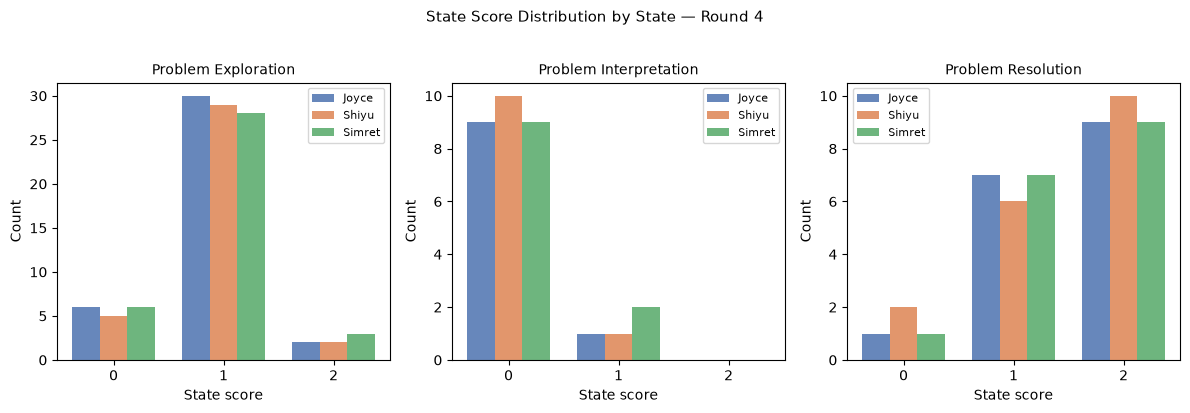

Mean ± SD of state_score per RA per state:


,Joyce mean±SD,Shiyu mean±SD,Simret mean±SD
State,,,
Problem Exploration,0.89 ± 0.45 (n=38),0.92 ± 0.44 (n=36),0.92 ± 0.49 (n=37)
Problem Interpretation,0.10 ± 0.32 (n=10),0.09 ± 0.30 (n=11),0.18 ± 0.40 (n=11)
Problem Resolution,1.47 ± 0.62 (n=17),1.44 ± 0.70 (n=18),1.47 ± 0.62 (n=17)


In [10]:
import matplotlib.pyplot as plt
import numpy as np

states = sorted(merged['state_joyce'].dropna().unique())
score_vals = [0, 1, 2]
ra_colors = {'joyce': '#4C72B0', 'shiyu': '#DD8452', 'simret': '#55A868'}
width = 0.25
x = np.arange(len(score_vals))

fig, axes = plt.subplots(1, len(states), figsize=(4 * len(states), 4), sharey=False)
if len(states) == 1:
    axes = [axes]

for ax, state in zip(axes, states):
    for i, (ra, df) in enumerate([('joyce', joyce), ('shiyu', shiyu), ('simret', simret)]):
        counts = df[df['state'] == state]['state_score'].value_counts().reindex(score_vals, fill_value=0)
        offset = (i - 1) * width
        ax.bar(x + offset, counts.values, width, label=ra.title(), color=ra_colors[ra], alpha=0.85)
    ax.set_title(state.title(), fontsize=10)
    ax.set_xlabel('State score')
    ax.set_xticks(x)
    ax.set_xticklabels(score_vals)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('State Score Distribution by State — Round 4', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("Mean ± SD of state_score per RA per state:")
rows = []
for state in states:
    row = {'State': state.title()}
    for ra, df in [('Joyce', joyce), ('Shiyu', shiyu), ('Simret', simret)]:
        vals = df[df['state'] == state]['state_score'].dropna()
        row[f'{ra} mean±SD'] = f"{vals.mean():.2f} ± {vals.std():.2f}  (n={len(vals)})"
    rows.append(row)
display(pd.DataFrame(rows).set_index('State'))

## 6. Combined Annotations CSV

Merges all three RAs' annotations into a single file. All rows retained. Output: `round4_combined.csv`.

**Derived columns:** `state_difference` (0 = all unanimous, 1 = any disagree, NaN if any missing); `score_range` (max − min across all three RAs).

In [11]:
# joyce, shiyu, simret already loaded and normalized from Section 5
combined = joyce[KEY_COLS + ['customer', 'CSR', 'state', 'state_score', 'note']].rename(
    columns={'state': 'state_joyce', 'state_score': 'state_score_joyce', 'note': 'note_joyce'}
).merge(
    shiyu[KEY_COLS + ['state', 'state_score', 'note']].rename(
        columns={'state': 'state_shiyu', 'state_score': 'state_score_shiyu', 'note': 'note_shiyu'}),
    on=KEY_COLS, how='left'
).merge(
    simret[KEY_COLS + ['state', 'state_score', 'note']].rename(
        columns={'state': 'state_simret', 'state_score': 'state_score_simret', 'note': 'note_simret'}),
    on=KEY_COLS, how='left'
)

def state_diff_3(r):
    vals = [r['state_joyce'], r['state_shiyu'], r['state_simret']]
    if any(pd.isna(v) for v in vals):
        return np.nan
    return 0 if len(set(vals)) == 1 else 1

def score_range_3(r):
    vals = [r['state_score_joyce'], r['state_score_shiyu'], r['state_score_simret']]
    valid = [v for v in vals if pd.notna(v)]
    return max(valid) - min(valid) if len(valid) >= 2 else np.nan

combined['state_difference'] = combined.apply(state_diff_3, axis=1)
combined['score_range']      = combined.apply(score_range_3, axis=1)

out_path = os.path.join(OUTPUT_DIR, 'round4_combined.csv')
combined.to_csv(out_path, index=False)

n_all = combined[['state_joyce', 'state_shiyu', 'state_simret']].notna().all(axis=1).sum()
print(f"Saved {len(combined)} rows × {len(combined.columns)} cols → {out_path}")
print(f"All 3 annotated: {n_all} / {len(combined)}")
print(f"\nstate_difference:  {combined['state_difference'].value_counts().sort_index().to_dict()}")
print(f"score_range:       {combined['score_range'].value_counts().sort_index().to_dict()}")
display(combined.head(3))

Saved 65 rows × 16 cols → ./round4_combined.csv
All 3 annotated: 65 / 65

state_difference:  {0: 63, 1: 2}
score_range:       {0: 60, 1: 5}


,source_folder,filename,segment,customer,CSR,state_joyce,state_score_joyce,note_joyce,state_shiyu,state_score_shiyu,note_shiyu,state_simret,state_score_simret,note_simret,state_difference,score_range
0,automotive_and_healthcare_insurance_inbound,2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e...,1,NaN,This call may be recorded.,problem interpretation,0,NaN,problem interpretation,0,NaN,problem interpretation,0,NaN,0,0
1,automotive_and_healthcare_insurance_inbound,2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e...,2,That's fine with me.,"Hello, this is [PERSON_NAME] with [ORGANIZATIO...",problem interpretation,0,two csr？,problem interpretation,0,NaN,problem interpretation,1,NaN,0,1
2,automotive_and_healthcare_insurance_inbound,2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e...,3,"Yes, I am.","Okay, wonderful. It's a pleasure to meet you a...",problem interpretation,0,NaN,problem interpretation,0,courtsey; it also might be exploration for 0,problem interpretation,0,NaN,0,0


## 7. LLM Prediction & Agreement (4th Round)

Generates LLM `state` + `state_score` predictions for the 65 round-4 CSR turns using the RA rubric, then measures agreement between the 3 RAs and the LLM.

- **Model:** current run is `gpt-4o` (**v4**). v1–v3 used `gpt-4.1-mini-2025-04-14`. JSON mode, temperature 0, resume-safe.
- **Input per turn:** running conversation history + current customer/CSR text. **v3 also passes `previous_state` / `previous_score`** from the model's own prior prediction on this call (sequential within a transcript).
- **Rubric versions** are frozen in `experiments/v1`, `experiments/v2`, `experiments/v3` (prompts, model, outputs, metrics).
  - **v1:** original rubric (`round4_llm.csv`). Courtesy dump + strict closings.
  - **v2:** RA-aligned persistence / closings / advice-as-resolution (`round4_llm_v2.csv`).
  - **v3:** tighter persistence + previous-state (`round4_llm_v3.csv`), still mini.
  - **v4 (current):** same prompt as v3, model `gpt-4o` (`round4_llm_v4.csv`).
- **Agreement:** (7.4–7.7) LLM as 4th rater; (7.8–7.9) few-shot; (7.10) v1/v2/v3 plots.

### 7.1 Setup & Rubric Prompt


In [ ]:
import os
import json
import time

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

MODEL      = "gpt-4o"
RUBRIC_VERSION = "v4"
KEY_COLS   = ["source_folder", "filename", "segment"]
# Round-4 completed CSVs live next to this notebook if OUTPUT_DIR has no copies.
if not os.path.exists(os.path.join(OUTPUT_DIR, "round4_joyce_completed.csv")):
    OUTPUT_DIR = "."
LLM_OUTPUT = os.path.join(OUTPUT_DIR, "round4_llm_v4.csv")

SYSTEM_PROMPT = (
    "You are an expert evaluator of customer service problem-handling skills. "
    "Classify the current CSR turn using the conversation history and Previous state. "
    "Persist Previous state only when the CSR is acknowledging information just collected. "
    "Greetings, rapport, empty ASR, and off-task remarks are Problem Interpretation 0 even "
    "if Previous state was Exploration or Resolution. Do not infer understanding, actions, "
    "or outcomes that are not visible in the text. Do not invent company policies, "
    "procedures, system capabilities, or facts. Your judgments must be accurate, "
    "evidence-based, and consistent."
)

USER_TEMPLATE = """Task: Classify the CSR's current response into the single best-supported state, then score how well that behavior is performed. A response can belong to a state and still score 0.

States and scoring

1. Problem Interpretation: The CSR shows they understand the customer's problem usually in the early stages of conversations. The score reflects how deeply: do they just repeat what happened, or do they show they understand why it matters to this customer?
- 2: States the problem and shows they understand why it matters to the customer (what it costs them, what's at risk, or what they still need), based on what the customer actually said.
  - Example: "So the cancellation means you might miss your sister's wedding, and you still need to get there by tomorrow morning."
- 1: Correctly states what the specific problem is, but not why it matters to the customer.
  - Example: "So your flight for tomorrow morning has been cancelled."
- 0: Does not identify the customer's specific problem. This includes standalone apologies, sympathy, or acknowledgments that a problem occurred without saying what it is, and repeating a single detail (a name, date, or booking number) without the actual problem.
  - Example: "I'm so sorry for the inconvenience.": acknowledges a problem but doesn't say what it is.
- Scoring note: A response names the specific problem if it does so anywhere, including inside an apology or pleasantry. Only a response that names no specific problem scores 0. Do not discard problem content just because it appears inside courtesy.

2. Problem Exploration: The CSR asks for information from the customer. The score reflects whether the question actually helps understand or diagnose the problem, or is just routine.
- 2: Asks for information the customer hasn't given yet, AND this turn makes clear what specific thing they're trying to pin down (the cause, a constraint, some context, what the customer wants, or what they still need) — or it is a direct follow-up verification continuing a purpose stated in the immediately preceding CSR turn.
  - Example: "Was the package marked as delivered to your address, or did tracking stop before it arrived? That tells me whether this is a carrier issue or a wrong-address issue."
- 1: Asks a relevant question that invites more information, but does not make the diagnostic purpose explicit in this turn. This includes standard intake/quote/identity questions (name, spelling, date of birth, address, phone, zip, coverage type, deductibles, vehicle) even when the information is new and specific.
  - Example: "Can you tell me a bit more about what happened with the package?" / "Do you have current insurance?" / "What's your date of birth?"
- 0: Asks for something the customer has already provided, confirmation-echoes with no new question, or questions that don't help understand or diagnose the problem itself (off-task / chit-chat).
- Do not score 2 just because the question is specific or the customer has not answered it yet. Specificity without stated purpose is a 1.

3. Problem Resolution: The CSR does something about the problem, or says what happens next. The score reflects whether the action actually addresses the problem and tells the customer what to expect.
  Resolution includes: taking or proposing an action; recommending a course of action; reporting a lookup result (availability, price, stock number, "they don't have one"); telling the customer what happens next. Restating the situation in order to recommend or report a result is still Resolution, not Interpretation.
  Looking something up is Resolution only when the CSR reports a result, availability, price, recommendation, or next step. Narrating that they are still looking, with no result yet, is not Resolution.
- 2: Takes or proposes an action that addresses the problem, meeting at least two of the following: (a) takes an action, (b) proposes an action / gives a recommendation, (c) tells the customer the result and what happens next.
  - Example: "I've approved a replacement. It'll ship today and arrive within two business days, and you'll get a tracking email tonight."
- 1: Takes an action related to the problem but doesn't say what the customer can expect from it.
  - Example: "I've gone ahead and started a replacement for you." / "We're talking to the store down the street, and they don't have one."
- 0: The action doesn't address the problem, or is empty. This includes routine steps that move the process along regardless of the problem, just logging the complaint, vague escalation ("I'll escalate this") that doesn't say what or to whom, repeating a step that already failed, or a promise with no actual action. These may be procedurally necessary, but they don't work toward solving the problem itself.
  - Example: "I've noted your complaint on the account." / "I'll escalate this for you."
- Closing: If the CSR is wrapping up (goodbye, "have a good day", "talk to you soon", "all right", "bye") after an action or recommendation has already been made, or after the customer is thanking/okay-ing with no new outstanding request, assign Problem Resolution and score 2. Score 0 only if the CSR ends the call while a customer request is still clearly unanswered.

Selecting the state
1. Ignore greetings, apologies, sympathy, and politeness when they are mixed with real problem-handling: they never determine the state. Classify and score the problem-handling part.
2. State persistence: Use Previous state as the activity in progress. Persist it ONLY when the CSR is acknowledging information just collected (e.g. "Okay." after the customer gives an email, zip, or date of birth; repeating a number while still verifying). Score 0 if the turn adds no new question or action, unless it is a wrap-up after completed work (see Closing).
   Do NOT persist across:
   - greetings or rapport ("How are you?", "It's a pleasure to meet you", "How are you doing today?")
   - bare thanks after a verification is already complete
   - empty, incomplete, or vague ASR ("That's.", "Possibly.", "Sounds good.", "Oh, okay. No problem.")
   Those are Problem Interpretation, score 0, even if Previous state was Exploration or Resolution.
   A one-word agreement to a customer request mid-intake ("Sure." when asked to email) stays Exploration unless the CSR actually performs or describes the action.
   Willingness to act with no action yet ("Okay. I can handle that.") is Problem Resolution, score 0.
3. Courtesy-only Interpretation 0: start-of-call IVR/recording notices, greetings, rapport, off-task chit-chat, and empty ASR — even when Previous state was Exploration or Resolution.
4. An opening question that invites the customer to state their need ("How am I assisting you?", "Are you looking for home or auto?") is Problem Exploration, even if the turn also contains a greeting. "How are you?" / "How are you doing today?" is rapport, not an opening need question — score Interpretation 0.
5. Among real content, pick the state with the strongest support in the text. If a turn contains multiple states, use this priority:
   a. Resolution > Exploration > Interpretation
   Advice/recommendation = Resolution. A reported lookup result = Resolution. Asking the customer a question = Exploration. Restating the problem without asking or acting = Interpretation.
   If the turn both reports a result and asks a question, still choose Resolution.

Scoring rules
- Use earlier conversation and Previous state to know what activity is in progress, what was already asked, and whether work is already complete. Judge the current turn against that activity, not as an isolated sentence.
- Repetitive or unsupported responses score 0 even when they clearly belong to a state.
- The examples show the level of each score, not the only wording that qualifies: do not pattern-match on them. Score only what's visible. Do not invent policies, actions, or facts.

Input
Previous state: "{previous_state}"
Previous score: "{previous_score}"
Conversation History: "{conversation_history}"
Customer's Latest Message: "{customer_message}"
CSR's Current Response: "{csr_response}"

Output: Return exactly one valid JSON object, with no Markdown, code fences, or surrounding text:
{{
"state": "Problem Interpretation | Problem Exploration | Problem Resolution",
"score": 0,
"explanation": "Concise, evidence-based justification grounded in the CSR's current response and the activity in progress."
}}"""


def format_user(conversation_history, customer_message, csr_response,
                previous_state="(start of call)", previous_score="(none)"):
    return USER_TEMPLATE.format(
        conversation_history=conversation_history,
        customer_message=customer_message,
        csr_response=csr_response,
        previous_state=previous_state,
        previous_score=previous_score,
    )


print(f"Model: {MODEL}  |  rubric: {RUBRIC_VERSION}")
print(f"Output: {LLM_OUTPUT}")


### 7.2 Build LLM Inputs (running conversation history)

Text is identical across RAs, so the segment text is read from Joyce's completed file. For each CSR turn, `conversation_history` is built from all prior Customer/CSR exchanges in the same transcript.

In [13]:
# Segment text is identical across RAs — use Joyce's completed file
text_src = pd.read_csv(os.path.join(OUTPUT_DIR, "round4_joyce_completed.csv"))
text_src = (text_src[KEY_COLS + ["customer", "CSR"]]
            .sort_values(["source_folder", "filename", "segment"])
            .reset_index(drop=True))


def build_histories(group):
    """Running history for each row = all prior Customer/CSR exchanges in the call."""
    histories, lines = [], []
    for _, r in group.iterrows():
        histories.append("\n".join(lines) if lines else "(start of call)")
        cust = r["customer"]
        if pd.notna(cust) and str(cust).strip():
            lines.append(f"Customer: {str(cust).strip()}")
        csr = r["CSR"]
        if pd.notna(csr) and str(csr).strip():
            lines.append(f"CSR: {str(csr).strip()}")
    return histories


text_src["conversation_history"] = pd.Series([""] * len(text_src), dtype=object)
for _, grp in text_src.groupby(["source_folder", "filename"], sort=False):
    text_src.loc[grp.index, "conversation_history"] = build_histories(grp)

llm_input = text_src
print(f"Built {len(llm_input)} LLM input rows across {llm_input['filename'].nunique()} transcripts")
display(llm_input[["segment", "customer", "CSR", "conversation_history"]].head(3))

Built 65 LLM input rows across 3 transcripts


,segment,customer,CSR,conversation_history
0,1,Thank you.,Your call is being transferred to one of our t...,(start of call)
1,2,"Auto. I wasn't looking for anything, but they ...",Okay. Do you have current insurance?,Customer: Thank you.\nCSR: Your call is being ...
2,3,Yes.,Okay. Do you have anything on your driving rec...,Customer: Thank you.\nCSR: Your call is being ...


### 7.3 Annotate with LLM (resume-safe, sequential previous-state)

Walks each transcript in segment order. `previous_state` / `previous_score` are this model's own labels on the prior CSR turn in the same call (or `(start of call)` / `(none)` on the first turn). Re-running resumes from `round4_llm_v4.csv`; delete that file to force a full re-run after a prompt change.


In [ ]:
# Sequential within each transcript so previous_state is well-defined.
llm_input_seq = llm_input.sort_values(["source_folder", "filename", "segment"]).reset_index(drop=True)

if os.path.exists(LLM_OUTPUT):
    llm_done = pd.read_csv(LLM_OUTPUT)
    done_map = {tuple(r[k] for k in KEY_COLS): r for r in llm_done.to_dict("records")}
    print(f"Resuming: {len(done_map)} segments already annotated")
else:
    done_map = {}

records = []
n_new = 0
prev_fn, prev_state, prev_score = None, "(start of call)", "(none)"

for _, r in llm_input_seq.iterrows():
    fn = (r["source_folder"], r["filename"])
    if fn != prev_fn:
        prev_state, prev_score = "(start of call)", "(none)"
        prev_fn = fn
    key = tuple(r[k] for k in KEY_COLS)
    if key in done_map:
        rec = done_map[key]
    else:
        user_msg = format_user(
            conversation_history=r["conversation_history"],
            customer_message="(CSR spoke first)" if pd.isna(r["customer"]) else str(r["customer"]).strip(),
            csr_response=str(r["CSR"]).strip(),
            previous_state=prev_state,
            previous_score=prev_score,
        )
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "system", "content": SYSTEM_PROMPT},
                      {"role": "user", "content": user_msg}],
            response_format={"type": "json_object"},
            temperature=0,
        )
        obj = json.loads(resp.choices[0].message.content)
        rec = {
            "source_folder": r["source_folder"], "filename": r["filename"], "segment": r["segment"],
            "state_llm": obj.get("state"), "score_llm": obj.get("score"),
            "explanation_llm": obj.get("explanation"),
            "previous_state": prev_state, "previous_score": prev_score,
        }
        n_new += 1
        if n_new % 10 == 0:
            print(f"  {n_new} new calls done")
        time.sleep(0.15)
    records.append(rec)
    prev_state = rec["state_llm"] if pd.notna(rec.get("state_llm")) else prev_state
    prev_score = rec["score_llm"] if pd.notna(rec.get("score_llm")) else prev_score
    pd.DataFrame(records).to_csv(LLM_OUTPUT, index=False)

llm_df = pd.DataFrame(records)
print(f"\nLLM annotations: {len(llm_df)} → {LLM_OUTPUT}  (new API calls: {n_new})")
print("state_llm:", llm_df["state_llm"].value_counts().to_dict())
print("score_llm:", llm_df["score_llm"].value_counts().sort_index().to_dict())
display(llm_df.head(3))


### 7.4 State Agreement — LLM as 4th Rater

LLM state labels are normalized to lowercase to match the RA labels, then compared 4-way (Krippendorff α, Fleiss κ) and via all 6 pairwise Cohen's κ.

In [15]:
import krippendorff as kd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from itertools import combinations


def _norm(s):
    return np.nan if pd.isna(s) else str(s).strip().lower()


# Load 3 RAs + LLM, normalize states
ra = {}
for name in ["joyce", "shiyu", "simret"]:
    d = pd.read_csv(os.path.join(OUTPUT_DIR, f"round4_{name}_completed.csv"))
    d["state"] = d["state"].map(_norm)
    ra[name] = d[KEY_COLS + ["state", "state_score"]].rename(
        columns={"state": f"state_{name}", "state_score": f"score_{name}"})

llm = pd.read_csv(LLM_OUTPUT)
llm["state_llm"] = llm["state_llm"].map(_norm)
llm_m = llm[KEY_COLS + ["state_llm", "score_llm"]].rename(columns={"score_llm": "score_llm"})

m = (ra["joyce"].merge(ra["shiyu"], on=KEY_COLS)
                .merge(ra["simret"], on=KEY_COLS)
                .merge(llm_m, on=KEY_COLS))
print(f"4-way merged: {len(m)} segments")

raters = ["joyce", "shiyu", "simret", "llm"]
all_states = sorted(set().union(*[set(m[f"state_{r}"].dropna()) for r in raters]))
s2i = {s: i for i, s in enumerate(all_states)}
print("states:", all_states)

# Krippendorff (nominal, 4 raters)
rel = np.array([[s2i.get(v, np.nan) for v in m[f"state_{r}"]] for r in raters], dtype=float)
alpha4 = kd.alpha(rel, level_of_measurement="nominal")
# Fleiss (4 raters)
mat = np.column_stack([m[f"state_{r}"].map(s2i).values for r in raters])
tab, _ = aggregate_raters(mat, n_cat=len(all_states))
kf4 = fleiss_kappa(tab)

print(f"\n=== State agreement, LLM as 4th rater (n={len(m)}) ===")
print(f"Krippendorff α (nominal, 4 raters): {alpha4:.3f}")
print(f"Fleiss κ (nominal, 4 raters):       {kf4:.3f}")

print("\nPairwise Cohen's κ (unweighted):")
for a, b in combinations(raters, 2):
    k = cohen_kappa_score(m[f"state_{a}"], m[f"state_{b}"])
    tag = "  (RA–LLM)" if "llm" in (a, b) else ""
    print(f"  {a:6} vs {b:6}: {k:.3f}{tag}")

print("\nLLM vs each RA — state exact-match %:")
for r in ["joyce", "shiyu", "simret"]:
    acc = (m["state_llm"] == m[f"state_{r}"]).mean()
    print(f"  llm vs {r:6}: {100 * acc:.1f}%")

4-way merged: 65 segments
states: ['problem exploration', 'problem interpretation', 'problem resolution']

=== State agreement, LLM as 4th rater (n=65) ===
Krippendorff α (nominal, 4 raters): 0.779
Fleiss κ (nominal, 4 raters):       0.778

Pairwise Cohen's κ (unweighted):
  joyce  vs shiyu : 0.947
  joyce  vs simret: 0.973
  joyce  vs llm   : 0.589  (RA–LLM)
  shiyu  vs simret: 0.974
  shiyu  vs llm   : 0.595  (RA–LLM)
  simret vs llm   : 0.617  (RA–LLM)

LLM vs each RA — state exact-match %:
  llm vs joyce : 75.4%
  llm vs shiyu : 75.4%
  llm vs simret: 76.9%


### 7.5 State Score Agreement — Unanimous-State Rows

Mirrors Section 5.1. Score agreement is computed on rows where all four raters agree on the state (scores are only comparable within the same state), plus per-RA LLM score agreement on pairwise state-matched rows (more data).

In [16]:
# Unanimous state across all 4 raters
u = m[(m["state_joyce"] == m["state_shiyu"]) &
      (m["state_joyce"] == m["state_simret"]) &
      (m["state_joyce"] == m["state_llm"])].copy()
print(f"Unanimous-state (all 4) segments: {len(u)}/{len(m)} ({100 * len(u) / len(m):.1f}%)\n")


def _sc(df, r):
    return df[f"score_{r}"].astype(int)


print(f"=== Score agreement — 4-way unanimous-state rows (n={len(u)}) ===")
for a, b in combinations(raters, 2):
    s1, s2 = _sc(u, a), _sc(u, b)
    if len(u) == 0 or s1.nunique() == 1 or s2.nunique() == 1:
        print(f"  {a:6} vs {b:6}: zero var / empty")
    else:
        kuw = cohen_kappa_score(s1, s2, labels=[0, 1, 2])
        kln = cohen_kappa_score(s1, s2, weights="linear", labels=[0, 1, 2])
        print(f"  {a:6} vs {b:6}: unweighted={kuw:.3f}  linear={kln:.3f}")

# Fleiss + ICC (4-way) on unanimous rows
if len(u) >= 5:
    smat = np.column_stack([_sc(u, r).values for r in raters])
    stab, _ = aggregate_raters(smat, n_cat=3)
    print(f"\nFleiss κ (scores as categories): {fleiss_kappa(stab):.3f}")
    nrow = len(u)
    long4 = pd.DataFrame({
        "item":   list(range(nrow)) * 4,
        "rater":  sum([[r] * nrow for r in raters], []),
        "rating": sum([_sc(u, r).tolist() for r in raters], []),
    })
    icc = pg.intraclass_corr(data=long4, targets="item", raters="rater", ratings="rating")
    a1 = icc[icc["Type"] == "ICC(A,1)"].iloc[0]
    ak = icc[icc["Type"] == "ICC(A,k)"].iloc[0]
    print(f"ICC(A,1): {a1['ICC']:.3f}  95% CI [{a1['CI95'][0]:.3f}, {a1['CI95'][1]:.3f}]")
    print(f"ICC(A,4): {ak['ICC']:.3f}  95% CI [{ak['CI95'][0]:.3f}, {ak['CI95'][1]:.3f}]")

# LLM vs each RA — score agreement on rows where that pair agrees on state
print("\n=== LLM vs each RA — score agreement on pairwise state-matched rows ===")
for r in ["joyce", "shiyu", "simret"]:
    sub = m[m["state_llm"] == m[f"state_{r}"]]
    s1, s2 = sub["score_llm"].astype(int), sub[f"score_{r}"].astype(int)
    if len(sub) < 2 or s1.nunique() == 1 or s2.nunique() == 1:
        print(f"  llm vs {r:6} (n={len(sub)}): zero var / too few")
    else:
        kuw = cohen_kappa_score(s1, s2, labels=[0, 1, 2])
        kln = cohen_kappa_score(s1, s2, weights="linear", labels=[0, 1, 2])
        mae = np.abs(s1.values - s2.values).mean()
        print(f"  llm vs {r:6} (n={len(sub)}): unweighted={kuw:.3f}  linear={kln:.3f}  MAE={mae:.2f}")

Unanimous-state (all 4) segments: 48/65 (73.8%)

=== Score agreement — 4-way unanimous-state rows (n=48) ===
  joyce  vs shiyu : unweighted=1.000  linear=1.000
  joyce  vs simret: unweighted=0.895  linear=0.910
  joyce  vs llm   : unweighted=0.377  linear=0.370
  shiyu  vs simret: unweighted=0.895  linear=0.910
  shiyu  vs llm   : unweighted=0.377  linear=0.370
  simret vs llm   : unweighted=0.315  linear=0.297

Fleiss κ (scores as categories): 0.631
ICC(A,1): 0.625  95% CI [0.490, 0.740]
ICC(A,4): 0.870  95% CI [0.800, 0.920]

=== LLM vs each RA — score agreement on pairwise state-matched rows ===
  llm vs joyce  (n=49): unweighted=0.385  linear=0.374  MAE=0.47
  llm vs shiyu  (n=49): unweighted=0.392  linear=0.388  MAE=0.47
  llm vs simret (n=50): unweighted=0.340  linear=0.322  MAE=0.52


### 7.6 LLM vs RA Consensus

RA consensus state = majority vote across the 3 RAs (NaN when all three differ). RA score = mean across the 3 RAs. Compares the LLM to this consensus.

In [17]:
from collections import Counter


def majority_state(r):
    vals = [r["state_joyce"], r["state_shiyu"], r["state_simret"]]
    top, n = Counter(vals).most_common(1)[0]
    return top if n >= 2 else np.nan


m["state_consensus"] = m.apply(majority_state, axis=1)
m["score_ra_mean"] = m[["score_joyce", "score_shiyu", "score_simret"]].astype(float).mean(axis=1)

has_cons = m["state_consensus"].notna()
print(f"Rows with an RA majority state: {has_cons.sum()}/{len(m)}")

acc = (m.loc[has_cons, "state_llm"] == m.loc[has_cons, "state_consensus"]).mean()
kcons = cohen_kappa_score(m.loc[has_cons, "state_llm"], m.loc[has_cons, "state_consensus"])
print(f"\n=== LLM vs RA consensus ===")
print(f"State: exact-match {100 * acc:.1f}%  |  Cohen κ {kcons:.3f}  (n={int(has_cons.sum())})")

# Score: LLM vs RA-mean (continuous) — MAE + ICC(A,1)
mae = (m["score_llm"].astype(float) - m["score_ra_mean"]).abs().mean()
nrow = len(m)
long = pd.DataFrame({
    "item":   list(range(nrow)) * 2,
    "rater":  ["llm"] * nrow + ["ra_mean"] * nrow,
    "rating": m["score_llm"].astype(float).tolist() + m["score_ra_mean"].tolist(),
})
icc = pg.intraclass_corr(data=long, targets="item", raters="rater", ratings="rating")
a1 = icc[icc["Type"] == "ICC(A,1)"].iloc[0]
print(f"Score: MAE(llm, RA-mean) {mae:.2f}  |  ICC(A,1) {a1['ICC']:.3f}  "
      f"95% CI [{a1['CI95'][0]:.3f}, {a1['CI95'][1]:.3f}]")

Rows with an RA majority state: 65/65

=== LLM vs RA consensus ===
State: exact-match 76.9%  |  Cohen κ 0.617  (n=65)
Score: MAE(llm, RA-mean) 0.52  |  ICC(A,1) 0.352  95% CI [0.120, 0.550]


### 7.7 Combined Annotations CSV (with LLM)

Merges the 3 RAs and the LLM into a single file with 4-way `state_difference_4` (0 = all agree, 1 = any differ) and `score_range_4` (max − min). Output: `round4_combined_with_llm.csv`.

In [18]:
combined_llm = pd.read_csv(
    os.path.join(OUTPUT_DIR, "round4_joyce_completed.csv"))[KEY_COLS + ["customer", "CSR"]]

for name in ["joyce", "shiyu", "simret"]:
    d = pd.read_csv(os.path.join(OUTPUT_DIR, f"round4_{name}_completed.csv"))
    d["state"] = d["state"].map(_norm)
    combined_llm = combined_llm.merge(
        d[KEY_COLS + ["state", "state_score", "note"]].rename(columns={
            "state": f"state_{name}", "state_score": f"score_{name}", "note": f"note_{name}"}),
        on=KEY_COLS, how="left")

llm = pd.read_csv(LLM_OUTPUT)
llm["state_llm"] = llm["state_llm"].map(_norm)
combined_llm = combined_llm.merge(
    llm[KEY_COLS + ["state_llm", "score_llm", "explanation_llm"]], on=KEY_COLS, how="left")


def _diff4(r):
    vals = [r["state_joyce"], r["state_shiyu"], r["state_simret"], r["state_llm"]]
    if any(pd.isna(v) for v in vals):
        return np.nan
    return 0 if len(set(vals)) == 1 else 1


def _range4(r):
    vals = [r[f"score_{x}"] for x in ["joyce", "shiyu", "simret", "llm"]]
    v = [x for x in vals if pd.notna(x)]
    return max(v) - min(v) if len(v) >= 2 else np.nan


combined_llm["state_difference_4"] = combined_llm.apply(_diff4, axis=1)
combined_llm["score_range_4"] = combined_llm.apply(_range4, axis=1)

out_path = os.path.join(OUTPUT_DIR, "round4_combined_with_llm.csv")
combined_llm.to_csv(out_path, index=False)
print(f"Saved {len(combined_llm)} rows × {len(combined_llm.columns)} cols → {out_path}")
print(f"state_difference_4: {combined_llm['state_difference_4'].value_counts(dropna=False).sort_index().to_dict()}")
print(f"score_range_4:      {combined_llm['score_range_4'].value_counts(dropna=False).sort_index().to_dict()}")
display(combined_llm.head(3))

Saved 65 rows × 19 cols → ./round4_combined_with_llm.csv
state_difference_4: {0: 48, 1: 17}
score_range_4:      {0: 34, 1: 25, 2: 6}


,source_folder,filename,segment,customer,CSR,state_joyce,score_joyce,note_joyce,state_shiyu,score_shiyu,note_shiyu,state_simret,score_simret,note_simret,state_llm,score_llm,explanation_llm,state_difference_4,score_range_4
0,automotive_and_healthcare_insurance_inbound,2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e...,1,NaN,This call may be recorded.,problem interpretation,0,NaN,problem interpretation,0,NaN,problem interpretation,0,NaN,problem interpretation,0,The CSR's response only informs the customer t...,0,0
1,automotive_and_healthcare_insurance_inbound,2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e...,2,That's fine with me.,"Hello, this is [PERSON_NAME] with [ORGANIZATIO...",problem interpretation,0,two csr？,problem interpretation,0,NaN,problem interpretation,1,NaN,problem interpretation,0,The CSR's response is a scripted introduction ...,0,1
2,automotive_and_healthcare_insurance_inbound,2021-08-12-16-23-23_cd7d7e27-c8b9-484f-9e7e-6e...,3,"Yes, I am.","Okay, wonderful. It's a pleasure to meet you a...",problem interpretation,0,NaN,problem interpretation,0,courtsey; it also might be exploration for 0,problem interpretation,0,NaN,problem interpretation,0,The CSR's response is a polite greeting and in...,0,0


### 7.8 Few-shot Prediction

Re-runs the LLM with **static few-shot demonstrations** prepended as user→assistant message pairs (after the same system prompt). Demos mix RA-unanimous segments from **rounds 1–3** with RA-convention examples. Output: `round4_llm_fewshot_v3.csv`.

Note: few-shot is still one-shot-per-turn (no sequential previous-state), so v3's previous-state signal applies to **zero-shot** (`round4_llm_v3.csv`). Treat few-shot v3 as a prompt-only ablation.


In [ ]:
LLM_FEWSHOT = os.path.join(OUTPUT_DIR, "round4_llm_fewshot_v3.csv")

# Curated demos (edit freely). Explanations encode the v2 RA-aligned rubric.
FEWSHOT = [
    {"state": "Problem Interpretation", "score": 0,
     "history": "(start of call)",
     "customer": "(CSR spoke first)",
     "csr": "This call may be recorded. My name is [PERSON_NAME]. How you doing today?",
     "explanation": "Start-of-call greeting with no question and no in-progress activity. Courtesy-only turns default to Problem Interpretation and score 0."},
    {"state": "Problem Exploration", "score": 0,
     "history": "Customer: Hi, I'd like to make an appointment for my son.\nCSR: Okay, and do we know anybody else in your family here?",
     "customer": "Yes.",
     "csr": "Okay. And what's your son's name?",
     "explanation": "Asks for routine identifying information to process the appointment, not to diagnose a problem, so Problem Exploration, score 0."},
    {"state": "Problem Exploration", "score": 1,
     "history": "(qualifying the customer for insurance benefits)",
     "customer": "Sometime I think and sometime I don't.",
     "csr": "Okay. Who helps you make your healthcare decisions?",
     "explanation": "Asks a relevant question that invites more information but does not make the diagnostic purpose explicit, so Problem Exploration, score 1."},
    {"state": "Problem Exploration", "score": 2,
     "history": "(start of a Medicare benefits discussion)",
     "customer": "I'm doing kind of okay.",
     "csr": "So first I just want to verify a few things so we can pull up your available options. Just to confirm you are enrolled in Medicare A and B, is that correct?",
     "explanation": "Asks a new question and states why (to pull up available options), so Problem Exploration, score 2."},
    {"state": "Problem Exploration", "score": 0,
     "history": "CSR: And what's a good email for you?\nCustomer: Yeah. [EMAIL_ADDRESS] [EMAIL_ADDRESS].",
     "customer": "[EMAIL_ADDRESS].",
     "csr": "Okay.",
     "explanation": "The CSR is in the middle of gathering contact information. A bare acknowledgment does not change the state: keep Problem Exploration. The turn asks nothing new, so score 0."},
    {"state": "Problem Resolution", "score": 0,
     "history": "Customer: I don't remember what it was, and I haven't got anything yet.",
     "customer": "I do not know. I don't remember what it was. I hadn't got anything yet.",
     "csr": "Okay. All right, Ms. [PERSON_NAME]. Well, you have a great day, ma'am.",
     "explanation": "The CSR ends the call while the customer's issue is still unanswered. Closings with a clearly outstanding request score 0, so Problem Resolution, score 0."},
    {"state": "Problem Resolution", "score": 1,
     "history": "(wrapping up; the requested documents were discussed)",
     "customer": "All right, thank you.",
     "csr": "I'm going to email these to you.",
     "explanation": "States an action related to resolving the request (emailing the documents) but does not tell the customer what to expect from it, so Problem Resolution, score 1."},
    {"state": "Problem Resolution", "score": 2,
     "history": "(finalizing an appointment)",
     "customer": "Okay, perfect. Thank you.",
     "csr": "We'll plan to see [PERSON_NAME] on [DATE] at [TIME] in [LOCATION]. If you need anything between now and then just give us a call.",
     "explanation": "Confirms the concrete result (appointment set for a specific date, time, and location) and tells the customer what to do next, meeting multiple resolution criteria, so Problem Resolution, score 2."},
    {"state": "Problem Resolution", "score": 2,
     "history": "Customer has existing employer retirement coverage and called about additional Medicare benefits.\nCSR: So you have your current insurance through your retirement plan?",
     "customer": "Yes, I still have that too.",
     "csr": "What I would recommend is you just staying right where you're at because you have really great coverage through your past employer and we don't want to jeopardize that.",
     "explanation": "Recommending a course of action is Problem Resolution, not Interpretation, even though it restates why the coverage matters. The recommendation plus the reason meets score 2."},
    {"state": "Problem Resolution", "score": 2,
     "history": "CSR already took or promised the action the customer needed.\nCustomer: Thank you.",
     "customer": "Thank you.",
     "csr": "All right, bye.",
     "explanation": "Wrap-up after the work is done; the customer is thanking and has no new outstanding request. Closings in that situation are Problem Resolution, score 2."},
]

# Build static demo messages (user -> assistant pairs)
demo_messages = []
for d in FEWSHOT:
    demo_messages.append({"role": "user", "content": format_user(
        d["history"], d["customer"], d["csr"],
        d.get("previous_state", "(start of call)"), d.get("previous_score", "(none)"))})
    demo_messages.append({"role": "assistant", "content": json.dumps(
        {"state": d["state"], "score": d["score"], "explanation": d["explanation"]})})
print(f"{len(FEWSHOT)} demos -> {len(demo_messages)} demo messages")
print("cells:", [(d["state"].split()[-1], d["score"]) for d in FEWSHOT])

# Resume-safe few-shot annotation
if os.path.exists(LLM_FEWSHOT):
    fs_done = pd.read_csv(LLM_FEWSHOT)
    done_keys = set(map(tuple, fs_done[KEY_COLS].values))
    records = fs_done.to_dict("records")
    print(f"Resuming: {len(fs_done)} already annotated")
else:
    records, done_keys = [], set()

todo = [r for _, r in llm_input.iterrows() if tuple(r[KEY_COLS]) not in done_keys]
print(f"To annotate (few-shot): {len(todo)}\n")

for i, r in enumerate(todo, 1):
    # few-shot is not sequential here; previous_state is unknown so use start-of-call default
    query = {"role": "user", "content": format_user(
        r["conversation_history"],
        "(CSR spoke first)" if pd.isna(r["customer"]) else str(r["customer"]).strip(),
        str(r["CSR"]).strip())}
    resp = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "system", "content": SYSTEM_PROMPT}] + demo_messages + [query],
        response_format={"type": "json_object"},
        temperature=0,
    )
    obj = json.loads(resp.choices[0].message.content)
    records.append({**{k: r[k] for k in KEY_COLS},
                    "state_llm": obj.get("state"), "score_llm": obj.get("score"),
                    "explanation_llm": obj.get("explanation")})
    pd.DataFrame(records).to_csv(LLM_FEWSHOT, index=False)
    if i % 10 == 0 or i == len(todo):
        print(f"  {i}/{len(todo)} done")
    time.sleep(0.2)

fs_df = pd.DataFrame(records)
print(f"\nFew-shot annotations: {len(fs_df)} -> {LLM_FEWSHOT}")
print("state_llm:", fs_df["state_llm"].value_counts().to_dict())
print("score_llm:", fs_df["score_llm"].value_counts().sort_index().to_dict())


### 7.9 Zero-shot vs Few-shot Agreement Comparison

Same headline metrics computed for both LLM runs under **rubric v2**. If `round4_llm.csv` / `round4_llm_fewshot.csv` are still on disk, a second table compares rubric v1 vs v2. Higher is better for α / κ / ICC / accuracy; **lower** is better for MAE.


In [ ]:
import krippendorff as kd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
from collections import Counter


def _norm2(s):
    return np.nan if pd.isna(s) else str(s).strip().lower()


def agreement_summary(llm_path):
    ra = {}
    for name in ["joyce", "shiyu", "simret"]:
        d = pd.read_csv(os.path.join(OUTPUT_DIR, f"round4_{name}_completed.csv"))
        d["state"] = d["state"].map(_norm2)
        ra[name] = d[KEY_COLS + ["state", "state_score"]].rename(
            columns={"state": f"state_{name}", "state_score": f"score_{name}"})
    llm = pd.read_csv(llm_path)
    llm["state_llm"] = llm["state_llm"].map(_norm2)
    llm = llm[KEY_COLS + ["state_llm", "score_llm"]]
    m = (ra["joyce"].merge(ra["shiyu"], on=KEY_COLS)
                    .merge(ra["simret"], on=KEY_COLS).merge(llm, on=KEY_COLS))
    raters = ["joyce", "shiyu", "simret", "llm"]
    states = sorted(set().union(*[set(m[f"state_{r}"].dropna()) for r in raters]))
    s2i = {s: i for i, s in enumerate(states)}
    rel = np.array([[s2i.get(v, np.nan) for v in m[f"state_{r}"]] for r in raters], dtype=float)
    ka = kd.alpha(rel, level_of_measurement="nominal")
    mat = np.column_stack([m[f"state_{r}"].map(s2i).values for r in raters])
    tab, _ = aggregate_raters(mat, n_cat=len(states))
    kf = fleiss_kappa(tab)
    kl = {r: cohen_kappa_score(m["state_llm"], m[f"state_{r}"]) for r in ["joyce", "shiyu", "simret"]}

    def maj(row):
        vals = [row[f"state_{r}"] for r in ["joyce", "shiyu", "simret"]]
        top, n = Counter(vals).most_common(1)[0]
        return top if n >= 2 else np.nan

    m["cons"] = m.apply(maj, axis=1)
    hc = m["cons"].notna()
    acc = (m.loc[hc, "state_llm"] == m.loc[hc, "cons"]).mean()
    kcons = cohen_kappa_score(m.loc[hc, "state_llm"], m.loc[hc, "cons"])
    ramean = m[[f"score_{r}" for r in ["joyce", "shiyu", "simret"]]].astype(float).mean(axis=1)
    mae = (m["score_llm"].astype(float) - ramean).abs().mean()
    nrow = len(m)
    lg = pd.DataFrame({"item": list(range(nrow)) * 2, "rater": ["llm"] * nrow + ["ram"] * nrow,
                       "rating": m["score_llm"].astype(float).tolist() + ramean.tolist()})
    icc = pg.intraclass_corr(data=lg, targets="item", raters="rater", ratings="rating")
    a1 = icc[icc["Type"] == "ICC(A,1)"].iloc[0]["ICC"]
    return {
        "Krippendorff α (state, 4-way)": ka,
        "Fleiss κ (state, 4-way)": kf,
        "κ LLM–Joyce (state)": kl["joyce"],
        "κ LLM–Shiyu (state)": kl["shiyu"],
        "κ LLM–Simret (state)": kl["simret"],
        "State acc vs consensus": acc,
        "κ vs consensus (state)": kcons,
        "Score MAE vs RA-mean (lower=better)": mae,
        "Score ICC(A,1) vs RA-mean": a1,
    }


zs = agreement_summary(LLM_OUTPUT)
print("=== Current LLM_OUTPUT vs few-shot (if present) ===")
print("zero-shot file:", LLM_OUTPUT)
if os.path.exists(LLM_FEWSHOT):
    fs = agreement_summary(LLM_FEWSHOT)
    comp = pd.DataFrame({"zero-shot": zs, "few-shot": fs})
    comp["Δ (few − zero)"] = comp["few-shot"] - comp["zero-shot"]
    display(comp.round(3))
else:
    display(pd.DataFrame({"zero-shot": zs}).round(3))
    print("No few-shot file at", LLM_FEWSHOT)

def _find_pred(*names):
    for name in names:
        for root in [OUTPUT_DIR, ".", os.path.join("experiments")]:
            p = name if name.startswith("experiments") else os.path.join(root, os.path.basename(name) if root != "experiments" else name)
            if os.path.exists(p):
                return p
        if os.path.exists(name):
            return name
    return None

wide = {}
pairs = [
    ("v1 zero-shot", "round4_llm.csv", os.path.join("experiments", "v1", "predictions_zero_shot.csv")),
    ("v1 few-shot", "round4_llm_fewshot.csv", os.path.join("experiments", "v1", "predictions_few_shot.csv")),
    ("v2 zero-shot", "round4_llm_v2.csv", os.path.join("experiments", "v2", "predictions_zero_shot.csv")),
    ("v2 few-shot", "round4_llm_fewshot_v2.csv", os.path.join("experiments", "v2", "predictions_few_shot.csv")),
    ("v3 zero-shot", "round4_llm_v3.csv", os.path.join("experiments", "v3", "predictions_zero_shot.csv")),
    ("v4 zero-shot", "round4_llm_v4.csv", os.path.join("experiments", "v4", "predictions_zero_shot.csv")),
]
for lab, *names in pairs:
    p = _find_pred(*names)
    if p:
        wide[lab] = agreement_summary(p)
        print(f"{lab}: {p}")
    else:
        print(f"{lab}: missing")
print("=== Rubric versions ===")
display(pd.DataFrame(wide).round(3))


### 7.10 Visualize rubric v1 vs v2 vs v3

Compares LLM runs against the same 3-RA gold labels. Needs `round4_llm.csv`, `round4_llm_v2.csv`, `round4_llm_v3.csv`, `round4_llm_v4.csv` (and few-shot files when present) next to the RA completed files. Frozen copies live in `experiments/v1`, `experiments/v2`, `experiments/v3`, `experiments/v4`.


Skipping missing runs: ['v3 few-shot']
Loaded 6 runs × 65 turns
  v1 zero-shot: ./round4_llm.csv
  v1 few-shot: ./round4_llm_fewshot.csv
  v2 zero-shot: ./round4_llm_v2.csv
  v2 few-shot: ./round4_llm_fewshot_v2.csv
  v3 zero-shot: ./round4_llm_v3.csv
  v4 zero-shot: ./round4_llm_v4.csv


,v1 zero-shot,v1 few-shot,v2 zero-shot,v2 few-shot,v3 zero-shot,v4 zero-shot
Krippendorff α,0.779,0.738,0.800,0.786,0.869,0.883
κ vs consensus,0.617,0.561,0.618,0.589,0.792,0.821
State accuracy,0.769,0.708,0.800,0.785,0.877,0.892
"Score ICC(A,1)",0.352,0.358,0.537,0.497,0.570,0.474
Score MAE,0.523,0.559,0.487,0.436,0.451,0.431
Fleiss κ,0.778,0.737,0.799,0.785,0.869,0.882


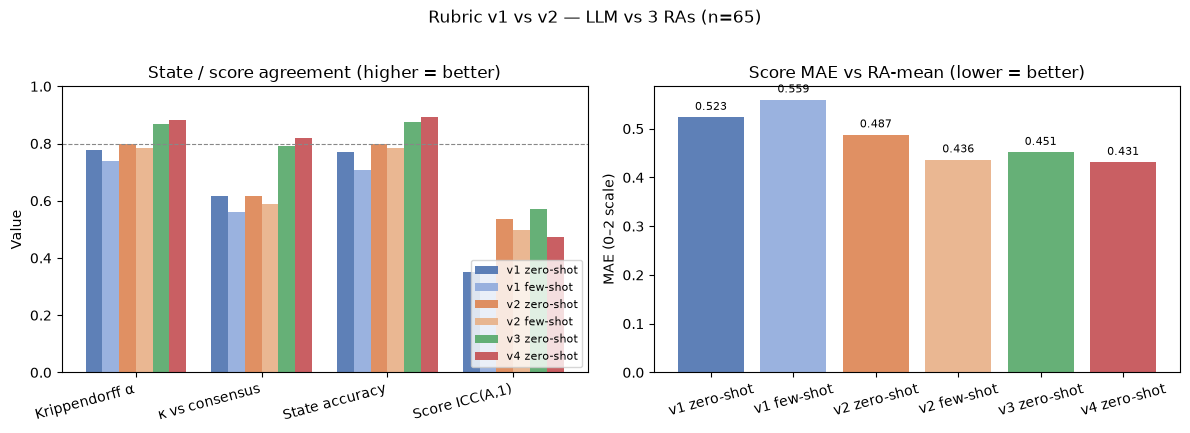

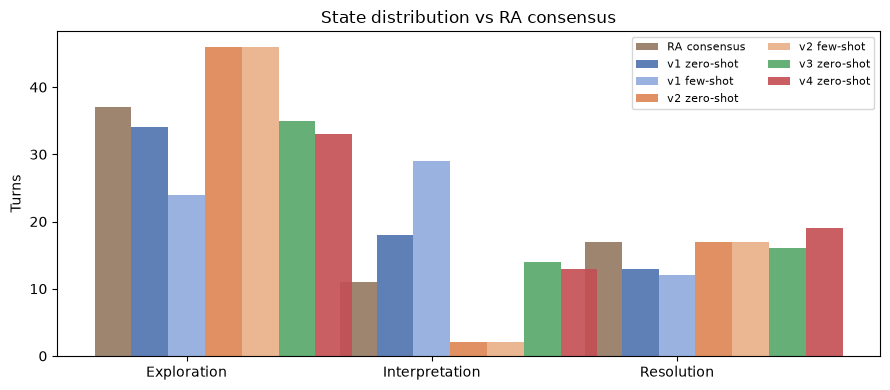

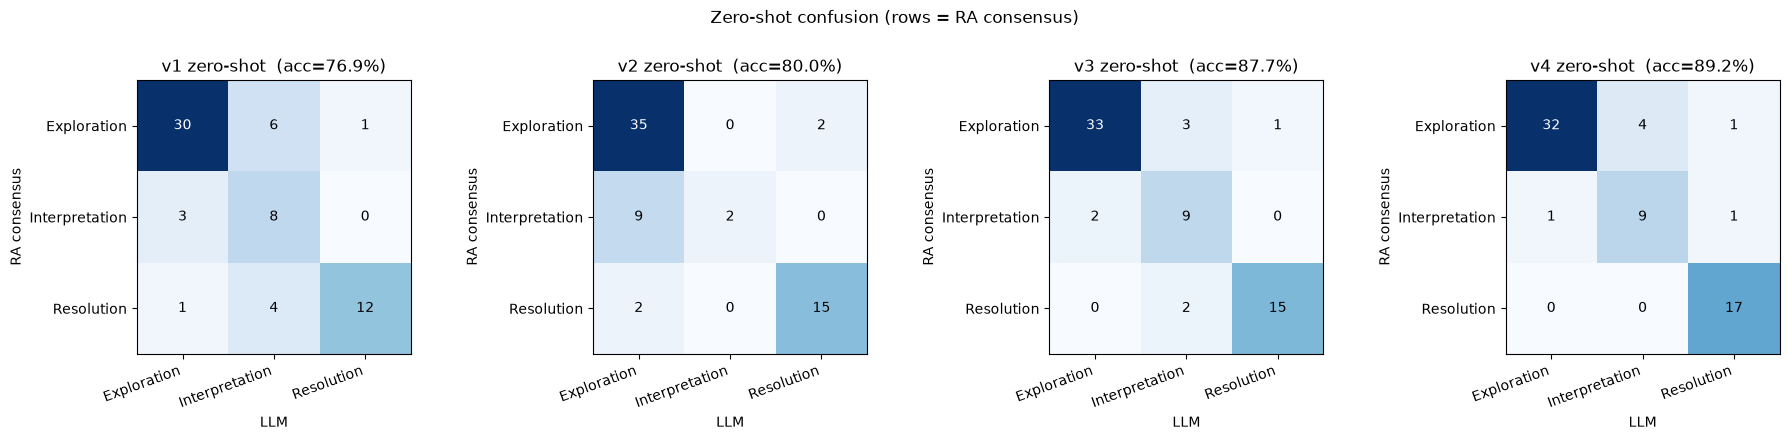

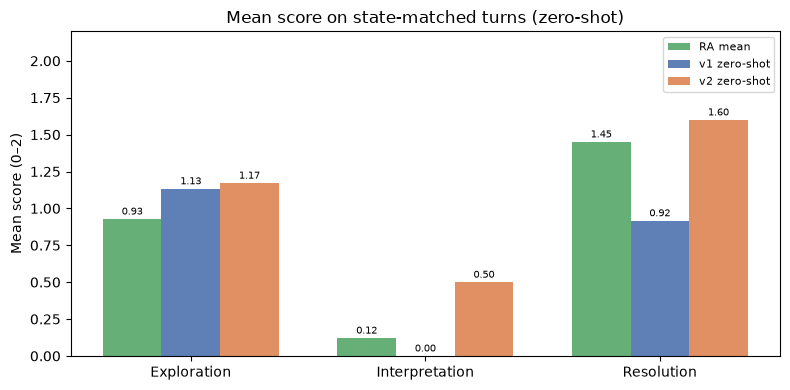

State errors vs RA consensus (zero-shot)


,v1 zero-shot,v2 zero-shot,v3 zero-shot,v4 zero-shot
pair,,,,
Exploration → Interpretation,6,0,3,4
Resolution → Interpretation,4,0,2,0
Interpretation → Exploration,3,9,2,1
Exploration → Resolution,1,2,1,1
Resolution → Exploration,1,2,0,0
Interpretation → Resolution,0,0,0,1


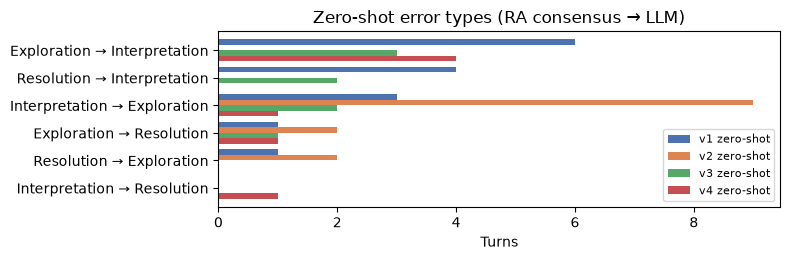

In [22]:
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import krippendorff as kd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

def _first_existing(*paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


_out = OUTPUT_DIR if "OUTPUT_DIR" in globals() else "."
_ra_dir = _first_existing(
    _out if os.path.exists(os.path.join(_out, "round4_joyce_completed.csv")) else None,
    "." if os.path.exists("round4_joyce_completed.csv") else None,
) or "."
_keys = KEY_COLS if "KEY_COLS" in globals() else ["source_folder", "filename", "segment"]
_short = {
    "problem exploration": "Exploration",
    "problem interpretation": "Interpretation",
    "problem resolution": "Resolution",
}
_run_spec = [
    ("v1 zero-shot", ["round4_llm.csv", os.path.join("experiments", "v1", "predictions_zero_shot.csv")]),
    ("v1 few-shot", ["round4_llm_fewshot.csv", os.path.join("experiments", "v1", "predictions_few_shot.csv")]),
    ("v2 zero-shot", ["round4_llm_v2.csv", os.path.join("experiments", "v2", "predictions_zero_shot.csv")]),
    ("v2 few-shot", ["round4_llm_fewshot_v2.csv", os.path.join("experiments", "v2", "predictions_few_shot.csv")]),
    ("v3 zero-shot", ["round4_llm_v3.csv", os.path.join("experiments", "v3", "predictions_zero_shot.csv")]),
    ("v3 few-shot", ["round4_llm_fewshot_v3.csv", os.path.join("experiments", "v3", "predictions_few_shot.csv")]),
    ("v4 zero-shot", ["round4_llm_v4.csv", os.path.join("experiments", "v4", "predictions_zero_shot.csv")]),
]
_runs = []
_skipped = []
for lab, names in _run_spec:
    cands = []
    for name in names:
        cands.append(os.path.join(_out, os.path.basename(name)) if not name.startswith("experiments") else None)
        cands.append(name)
        cands.append(os.path.join(_ra_dir, os.path.basename(name)))
    path = _first_existing(*cands)
    if path:
        _runs.append((lab, path))
    else:
        _skipped.append(lab)
_colors = {
    "v1 zero-shot": "#4C72B0",
    "v1 few-shot": "#8FAADC",
    "v2 zero-shot": "#DD8452",
    "v2 few-shot": "#E8B086",
    "v3 zero-shot": "#55A868",
    "v3 few-shot": "#8FCB9B",
    "v4 zero-shot": "#C44E52",
    "RA consensus": "#937860",
}


def _norm_viz(s):
    return np.nan if pd.isna(s) else str(s).strip().lower()


def _majority(row):
    vals = [row["state_joyce"], row["state_shiyu"], row["state_simret"]]
    top, n = Counter(vals).most_common(1)[0]
    return top if n >= 2 else np.nan


def _load_merged(llm_path):
    ra = {}
    for name in ["joyce", "shiyu", "simret"]:
        d = pd.read_csv(os.path.join(_ra_dir, f"round4_{name}_completed.csv"))
        d["state"] = d["state"].map(_norm_viz)
        ra[name] = d[_keys + ["state", "state_score"]].rename(
            columns={"state": f"state_{name}", "state_score": f"score_{name}"})
    llm = pd.read_csv(llm_path)
    llm["state_llm"] = llm["state_llm"].map(_norm_viz)
    llm["score_llm"] = llm["score_llm"].astype(float)
    m = (ra["joyce"].merge(ra["shiyu"], on=_keys)
                    .merge(ra["simret"], on=_keys)
                    .merge(llm[_keys + ["state_llm", "score_llm"]], on=_keys))
    m["cons"] = m.apply(_majority, axis=1)
    m["score_ra"] = m[["score_joyce", "score_shiyu", "score_simret"]].astype(float).mean(axis=1)
    return m


def _metrics(m):
    raters = ["joyce", "shiyu", "simret", "llm"]
    states = sorted(set().union(*[set(m[f"state_{r}"].dropna()) for r in raters]))
    s2i = {s: i for i, s in enumerate(states)}
    rel = np.array([[s2i.get(v, np.nan) for v in m[f"state_{r}"]] for r in raters], dtype=float)
    mat = np.column_stack([m[f"state_{r}"].map(s2i).values for r in raters])
    tab, _ = aggregate_raters(mat, n_cat=len(states))
    hc = m["cons"].notna()
    ramean = m["score_ra"]
    nrow = len(m)
    lg = pd.DataFrame({
        "item": list(range(nrow)) * 2,
        "rater": ["llm"] * nrow + ["ram"] * nrow,
        "rating": m["score_llm"].tolist() + ramean.tolist(),
    })
    icc = pg.intraclass_corr(data=lg, targets="item", raters="rater", ratings="rating")
    return {
        "Krippendorff α": kd.alpha(rel, level_of_measurement="nominal"),
        "κ vs consensus": cohen_kappa_score(m.loc[hc, "state_llm"], m.loc[hc, "cons"]),
        "State accuracy": (m.loc[hc, "state_llm"] == m.loc[hc, "cons"]).mean(),
        "Score ICC(A,1)": icc[icc["Type"] == "ICC(A,1)"].iloc[0]["ICC"],
        "Score MAE": (m["score_llm"] - ramean).abs().mean(),
        "Fleiss κ": fleiss_kappa(tab),
    }


if not _runs:
    raise FileNotFoundError("No LLM prediction CSVs found. Expected round4_llm*.csv or experiments/v*/predictions_*.csv")
if _skipped:
    print("Skipping missing runs:", _skipped)

merged = {lab: _load_merged(path) for lab, path in _runs}
metrics = pd.DataFrame({lab: _metrics(m) for lab, m in merged.items()})
print(f"Loaded {len(_runs)} runs × {len(next(iter(merged.values())))} turns")
for lab, path in _runs:
    print(f"  {lab}: {path}")
display(metrics.round(3))

# --- 1. Headline metrics ---
higher = ["Krippendorff α", "κ vs consensus", "State accuracy", "Score ICC(A,1)"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(higher))
nbar = len(metrics.columns)
width = 0.8 / max(nbar, 1)
for i, lab in enumerate(metrics.columns):
    axes[0].bar(x + (i - (nbar - 1) / 2) * width, metrics.loc[higher, lab].values,
                width, label=lab, color=_colors[lab], alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(higher, rotation=15, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Value")
axes[0].set_title("State / score agreement (higher = better)")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].axhline(0.8, color="#888888", ls="--", lw=0.8)

mae_labs = list(metrics.columns)
axes[1].bar(mae_labs, metrics.loc["Score MAE", mae_labs],
            color=[_colors[l] for l in mae_labs], alpha=0.9)
axes[1].set_ylabel("MAE (0–2 scale)")
axes[1].set_title("Score MAE vs RA-mean (lower = better)")
axes[1].tick_params(axis="x", rotation=15)
for i, lab in enumerate(mae_labs):
    axes[1].text(i, metrics.loc["Score MAE", lab] + 0.01,
                 f"{metrics.loc['Score MAE', lab]:.3f}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Rubric v1 vs v2 — LLM vs 3 RAs (n=65)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- 2. State mix ---
order = ["Exploration", "Interpretation", "Resolution"]
counts = pd.DataFrame({
    lab: merged[lab]["state_llm"].map(_short).value_counts() for lab in merged
})
counts["RA consensus"] = next(iter(merged.values()))["cons"].map(_short).value_counts()
counts = counts.reindex(order).fillna(0)
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(order))
width = 0.15
series = ["RA consensus"] + list(merged)
for i, lab in enumerate(series):
    ax.bar(x + (i - 2) * width, counts[lab].values, width, label=lab, color=_colors[lab], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Turns")
ax.set_title("State distribution vs RA consensus")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# --- 3. Confusion: zero-shot versions vs consensus ---
zs_labs = [lab for lab in merged if lab.endswith("zero-shot")]
fig, axes = plt.subplots(1, max(len(zs_labs), 1), figsize=(4.6 * max(len(zs_labs), 1), 4.2))
if max(len(zs_labs), 1) == 1:
    axes = [axes]
state_order = ["problem exploration", "problem interpretation", "problem resolution"]
tick = [_short[s] for s in state_order]
for ax, lab in zip(axes, zs_labs):
    ct = (pd.crosstab(merged[lab]["cons"], merged[lab]["state_llm"])
            .reindex(index=state_order, columns=state_order, fill_value=0))
    ax.imshow(ct.values, cmap="Blues", vmin=0, vmax=ct.values.max())
    ax.set_xticks(range(3), tick, rotation=20, ha="right")
    ax.set_yticks(range(3), tick)
    ax.set_xlabel("LLM")
    ax.set_ylabel("RA consensus")
    acc = (merged[lab]["state_llm"] == merged[lab]["cons"]).mean()
    ax.set_title(f"{lab}  (acc={100 * acc:.1f}%)")
    for r in range(3):
        for c in range(3):
            val = int(ct.values[r, c])
            ax.text(c, r, val, ha="center", va="center",
                    color="white" if val > ct.values.max() * 0.6 else "black", fontsize=10)
fig.suptitle("Zero-shot confusion (rows = RA consensus)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# --- 4. Score by state (zero-shot, state-matched rows) ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(order))
width = 0.25
for i, (lab, color) in enumerate([
    ("RA mean", "#55A868"),
    ("v1 zero-shot", _colors["v1 zero-shot"]),
    ("v2 zero-shot", _colors["v2 zero-shot"]),
]):
    means = []
    for st, raw in zip(order, state_order):
        if lab == "RA mean":
            sub = merged["v2 zero-shot"]
            sub = sub[sub["cons"] == raw]
            means.append(sub["score_ra"].mean() if len(sub) else np.nan)
        else:
            sub = merged[lab]
            sub = sub[(sub["cons"] == raw) & (sub["state_llm"] == raw)]
            means.append(sub["score_llm"].mean() if len(sub) else np.nan)
    ax.bar(x + (i - 1) * width, means, width, label=lab, color=color, alpha=0.9)
    for j, v in enumerate(means):
        if pd.notna(v):
            ax.text(x[j] + (i - 1) * width, v + 0.03, f"{v:.2f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylim(0, 2.2)
ax.set_ylabel("Mean score (0–2)")
ax.set_title("Mean score on state-matched turns (zero-shot)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- 5. Where zero-shot still disagrees with consensus ---
def _err_table(lab):
    m = merged[lab]
    dis = m[m["state_llm"] != m["cons"]].copy()
    dis["pair"] = dis["cons"].map(_short) + " → " + dis["state_llm"].map(_short)
    return dis["pair"].value_counts().rename(lab)

zs_labs = [lab for lab in merged if lab.endswith("zero-shot")]
err = pd.concat([_err_table(lab) for lab in zs_labs], axis=1).fillna(0).astype(int)
sort_col = "v1 zero-shot" if "v1 zero-shot" in err.columns else err.columns[0]
err = err.sort_values(sort_col, ascending=False)
print("State errors vs RA consensus (zero-shot)")
display(err)

n = len(zs_labs)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45 * len(err))))
y = np.arange(len(err))
width = min(0.8 / n, 0.25)
for i, lab in enumerate(zs_labs):
    ax.barh(y + (i - (n - 1) / 2) * width, err[lab], width, label=lab, color=_colors[lab])
ax.set_yticks(y, err.index)
ax.invert_yaxis()
ax.set_xlabel("Turns")
ax.set_title("Zero-shot error types (RA consensus → LLM)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
